# Implementace

**FAO MULTIPLEX TRADE NETWORK**

Zde analyzujeme různé typy obchodních vztahů mezi státy, získané z FAO (Organizace pro výživu a zemědělství OSN). Celosvětová síť importu/exportu potravin je ekonomická síť, kde vrstvy představují produkty, uzly jsou státy a hrany v každé vrstvě reprezentují vztahy importu/exportu konkrétního potravinového produktu mezi státy. Data byla získána z FAO a byla vytvořena vícevrstvá síť odpovídající obchodování v roce 2010.  

Multiplexní síť použitá v článku je podmnožinou úplné datové sady, která obsahuje 364 vrstev.

**Reference:**  
M. De Domenico, V. Nicosia, A. Arenas, a V. Latora - "Structural reducibility of multilayer networks" - Nature Communications 2015 6, 6864  
Originální data: [https://manliodedomenico.com/data.php](https://manliodedomenico.com/data.php)

**Formát souborů:**  
layerID nodeID nodeID weight  
364 vrstev Multiplex

**Uzly:** 214  
**Hrany:** 318 346  
**Typ:** Finanční, multiplexní, orientovaná, ohodnocená

miry, nahodna prochazka, flatenning, relevance, vizualizace, najit komunity, report s tabulky a obrazky a komentari popisujici, co jsme objevili, komentare jsou dulezite, nejake nalezy


## Načtení knihoven

In [112]:
import random
from pathlib import Path
from collections import Counter
from itertools import combinations

import community as community_louvain  # python-louvain
import matplotlib.pyplot as plt
import networkx as nx
import networkx.algorithms.community as nx_community
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering

import warnings
from scipy.cluster.hierarchy import ClusterWarning

In [113]:
random.seed(42)
np.random.seed(42)

In [114]:
SAVE_DIR = Path("../results/implementation")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

PLOT_DIR = SAVE_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

## Načtení datasetu

In [115]:
layers_path = Path("../data/FAO_Multiplex_Trade/fao_trade_layers.txt")
nodes_path = Path("../data/FAO_Multiplex_Trade/fao_trade_nodes.txt")
edges_path = Path("../data/FAO_Multiplex_Trade/fao_trade_multiplex.edges")

layers_df = pd.read_csv(layers_path, sep='\\s+')
nodes_df = pd.read_csv(nodes_path, sep='\\s+')
edges_df = pd.read_csv(edges_path, sep='\\s+',
                    names=['layerID', 'source', 'target', 'weight'])

## Výpis několika náhodných vrstev

In [116]:
layers_df.sample(10, random_state=13)['layerLabel']

214    Lettuce_and_chicory
251          Oil,_rapeseed
27             Food_wastes
61          Cake,_rapeseed
313                    Rye
330                Vanilla
248     Offals,_liver_duck
101           Cocoa,_paste
73            Eggs,_liquid
345               Rapeseed
Name: layerLabel, dtype: object

In [117]:
# Find layers with similar or general names (e.g., eggs, wheat, water, etc.)

keywords = ['egg', 'wheat', 'milk', 'rice', 'maize', 'corn', 'oil', 'meat', 'fish', 'fruit', 'vegetable', 'sugar', 'cheese', 'butter', 'soy', 'bean', 'barley', 'poultry', 'beef', 'pork', 'potato', 'tomato', 'apple', 'banana', 'onion', 'salt', 'wine', 'beer']

# Lowercase for case-insensitive search
layers_df['layerLabel_lower'] = layers_df['layerLabel'].str.lower()

matches = []
for kw in keywords:
    found = layers_df[layers_df['layerLabel_lower'].str.contains(kw)]
    if not found.empty:
        matches.append((kw, found['layerLabel'].unique()[:5]))  # show up to 5 examples per keyword

# Display results
for kw, labels in matches:
    print(f"Keyword '{kw}':")
    for label in labels:
        print(f"  - {label}")
    print()

Keyword 'egg':
  - Eggs,_hen,_in_shell
  - Eggplants_(aubergines)
  - Eggs,_liquid
  - Eggs,_dried
  - Eggs,_other_bird,_in_shell

Keyword 'wheat':
  - Flour,_wheat
  - Bran,_wheat
  - Buckwheat
  - Wheat

Keyword 'milk':
  - Cheese,_whole_cow_milk
  - Butter,_cow_milk
  - Buttermilk,_curdled,_acidified_milk
  - Cheese,_sheep_milk
  - Milk,_skimmed_dried

Keyword 'rice':
  - Bran,_rice
  - Beverages,_fermented_rice
  - Oil,_rice_bran
  - Rice,_milled
  - Rice,_husked

Keyword 'maize':
  - Bran,_maize
  - Flour,_maize
  - Cake,_maize
  - Maize
  - Oil,_maize

Keyword 'corn':
  - Sweet_corn_frozen
  - Sweet_corn_prep_or_preserved

Keyword 'oil':
  - Oil,_cottonseed
  - Oil,_palm
  - Oilseeds_nes
  - Oil,_sunflower
  - Oil,_boiled_etc

Keyword 'meat':
  - Meat,_chicken
  - Meat,_cattle
  - Meat,_cattle,_boneless_(beef_&_veal)
  - Meat,_pig,_preparations
  - Meat,_chicken,_canned

Keyword 'fruit':
  - Fruit,_prepared_nes
  - Fruit,_dried_nes
  - Fruit,_cooked,_homogenized_preparations
  - 

In [118]:
summary = pd.DataFrame({
    'Počet uzlů': [nodes_df.shape[0]],
    'Počet vrstev': [layers_df.shape[0]],
    'Počet hran': [edges_df.shape[0]]
})
summary

,Počet uzlů,Počet vrstev,Počet hran
0,214,364,318346


# Redukce na menší počet vrstev pomocí shlukování

## Vytvoření uzlů a hran pro jednotlivé vrstvy

In [119]:
layer_edges_path = SAVE_DIR / "layer_edges.csv"

# AI made this part of saving results so I feel inferior to the inner machinations of AI overlords
if layer_edges_path.exists():
    print("Loading precomputed layer edges...")
    layer_edges = {}
    df = pd.read_csv(layer_edges_path)
    for _, row in df.iterrows():
        layer_id = row['layerID']
        # Convert string representation of edges back to set of tuples
        edges = set(tuple(map(float, e.split('-'))) for e in row['edges'].split(';') if e)
        layer_edges[layer_id] = edges
else:
    print("CSV not found, computing layer edges...")
    layer_edges = {
        layer_id: set(
            tuple(row[['source', 'target']])
            for _, row in edges_df[edges_df['layerID'] == layer_id].iterrows()
        )
        for layer_id in layers_df['layerID']
    }
    # Save to CSV
    records = []
    for layer_id, edges in layer_edges.items():
        edge_str = ';'.join(f"{int(s)}-{int(t)}" for s, t in edges)
        records.append({'layerID': layer_id, 'edges': edge_str})
    pd.DataFrame(records).to_csv(layer_edges_path, index=False)

CSV not found, computing layer edges...


## Vypočet Jaccardovy vzdálenosti mezi vrstvami

In [120]:
layer_ids = list(layer_edges.keys())
n_layers = len(layer_ids)
jaccard_dist = np.zeros((n_layers, n_layers))

for i in range(n_layers):
    for j in range(n_layers):
        if i == j:
            jaccard_dist[i, j] = 0
        else:
            a = layer_edges[layer_ids[i]]
            b = layer_edges[layer_ids[j]]
            intersection = len(a & b)
            union = len(a | b)
            jaccard_dist[i, j] = 1 - intersection / union if union > 0 else 1

## Shlukování vrstev pomocí `Agglomerative` Clustering

In [121]:
warnings.filterwarnings("ignore", category=ClusterWarning) # some useless warning about similarity
clustering = AgglomerativeClustering(n_clusters=5, linkage='complete')
labels = clustering.fit_predict(jaccard_dist)

In [122]:
layers_df['jaccard_cluster'] = labels

## Agregace hran podle Jaccardových shluků vrstev


In [123]:
edges_with_cluster = edges_df.merge(layers_df[['layerID', 'jaccard_cluster']], on='layerID')
aggregated_edges_jaccard = edges_with_cluster.groupby(
    ['source', 'target', 'jaccard_cluster']
).agg({'weight': 'sum'}).reset_index()

In [124]:
jaccard_summary = layers_df.groupby('jaccard_cluster').agg(
    layer_count=('layerID', 'count'),
    example_labels=('layerLabel', lambda x: ', '.join(x.sample(min(3, len(x)))))
).reset_index()
jaccard_summary

,jaccard_cluster,layer_count,example_labels
0,0,44,"Tea,_mate_extracts, Pet_food, Glucose_and_dext..."
1,1,73,"Fat,_liver_prepared_(foie_gras), Oils,_fats_of..."
2,2,54,"Skins,_sheep,_dry_salted, Meat,_beef_and_veal_..."
3,3,91,"Lentils, Nutmeg,_mace_and_cardamoms, Molasses"
4,4,102,"Meat,_beef,_preparations, Offals,_pigs,_edible..."


## Aplikace nových kategorií vrstev na původní data

In [125]:
category_counts = layers_df['jaccard_cluster'].value_counts()
category_counts

jaccard_cluster
4    102
3     91
1     73
2     54
0     44
Name: count, dtype: int64

## Kombinace hran a váh podle nových kategorií vrstev

In [126]:
edges_with_category = edges_df.merge(layers_df[['layerID', 'jaccard_cluster']], on='layerID')

aggregated_edges = edges_with_category.groupby(
    ['source', 'target', 'jaccard_cluster']
).agg({
    'weight': 'sum',  # Sum weights across all layers in category
}).reset_index()

In [127]:
print(f"Aggregated edges: {len(aggregated_edges):,}")
print(f"Number of categories: {aggregated_edges['jaccard_cluster'].nunique()}")

Aggregated edges: 36,870
Number of categories: 5


## Rozdíl počtu hran před a po agregaci

In [128]:
original_edge_count = len(edges_df)
aggregated_edge_count = len(aggregated_edges)
reduction = (original_edge_count - aggregated_edge_count) / original_edge_count * 100

print(f"Original edge count: {original_edge_count:,}")
print(f"Aggregated edge count: {aggregated_edge_count:,}")
print(f"Reduction of edges: {reduction:.2f}%")

Original edge count: 318,346
Aggregated edge count: 36,870
Reduction of edges: 88.42%


## Ukázka několika náhodných hran po agregaci podle kategorií vrstev

In [129]:
aggregated_edges.head()

,source,target,jaccard_cluster,weight
0,1,2,0,28.0
1,1,2,4,33.0
2,1,4,4,59.0
3,1,5,4,30.0
4,1,6,0,159.0


## Vytvoření `networkx` grafu z agregovaných hran

### Vážené sítě

In [130]:
category_graphs_weighted = {}

# Prepare a mapping from nodeID to nodeLabel for fast lookup
node_id_to_label = nodes_df.set_index('nodeID')['nodeLabel'].to_dict()

for category in aggregated_edges['jaccard_cluster'].unique():
    cat_edges = aggregated_edges[aggregated_edges['jaccard_cluster'] == category]

    G = nx.DiGraph()
    
    # Přidat uzly podle všech zdrojů a cílů v této kategorii
    node_ids = set(cat_edges['source']).union(set(cat_edges['target']))
    for node_id in node_ids:
        label = node_id_to_label.get(node_id, str(node_id))
        G.add_node(node_id, label=label)
    
    # Přidat hrany
    for _, edge in cat_edges.iterrows():
        G.add_edge(edge['source'], edge['target'], weight=edge['weight'])
    
    category_graphs_weighted[category] = G

### Nevážené sítě

In [131]:
category_graphs_un_weighted = {}

for category in aggregated_edges['jaccard_cluster'].unique():

    cat_edges = aggregated_edges[aggregated_edges['jaccard_cluster'] == category]

    G_unweighted = nx.DiGraph()
    node_ids = set(cat_edges['source']).union(set(cat_edges['target']))
    for node_id in node_ids:
        label = node_id_to_label.get(node_id, str(node_id))
        G_unweighted.add_node(node_id, label=label)

    for _, edge in cat_edges.iterrows():
        G_unweighted.add_edge(edge['source'], edge['target'])

    category_graphs_un_weighted[category] = G_unweighted

## Statistiky nově vytvořených grafů podle kategorií vrstev 

### Vážené sítě

In [132]:
stats_weighted = []
for category, graph in category_graphs_weighted.items():
    weighted_in_deg = [deg for _, deg in graph.in_degree(weight='weight')]
    weighted_out_deg = [deg for _, deg in graph.out_degree(weight='weight')]
    weighted_total_deg = [deg for _, deg in graph.degree(weight='weight')]
    num_nodes = graph.number_of_nodes()
    num_edges = graph.number_of_edges()
    num_strongly_connected = nx.number_strongly_connected_components(graph)
    num_weakly_connected = nx.number_weakly_connected_components(graph)
    num_in_zero = sum(1 for n, d in graph.in_degree(weight='weight') if d == 0)
    num_out_zero = sum(1 for n, d in graph.out_degree(weight='weight') if d == 0)
    degree_counts = Counter(weighted_total_deg)

    stats_weighted.append({
        "Category": category,
        "Nodes": num_nodes,
        "Edges": num_edges,
        "Mean in-degree": np.mean(weighted_in_deg),
        "Median in-degree": np.median(weighted_in_deg),
        "Mean out-degree": np.mean(weighted_out_deg),
        "Median out-degree": np.median(weighted_out_deg),
        "Max degree": np.max(weighted_total_deg),
        "Min degree": np.min(weighted_total_deg),
        "Isolated nodes": (np.array(weighted_total_deg) == 0).sum(),
        "Strongly connected components": num_strongly_connected,
        "Weakly connected components": num_weakly_connected,
        "Nodes with in-degree 0": num_in_zero,
        "Nodes with out-degree 0": num_out_zero,
        "Most common degree": degree_counts.most_common(1)[0][0] if degree_counts else None
    })

pd.DataFrame(stats_weighted)

,Category,Nodes,Edges,Mean in-degree,Median in-degree,Mean out-degree,Median out-degree,Max degree,Min degree,Isolated nodes,Strongly connected components,Weakly connected components,Nodes with in-degree 0,Nodes with out-degree 0,Most common degree
0,0,214,11412,1.622538e+06,136125.5,1.622538e+06,66092.5,66039106.0,6.0,0,82,1,81,0,7.0
1,4,209,8870,1.876176e+06,184694.0,1.876176e+06,71501.0,70103721.0,1.0,0,77,1,76,0,2.0
2,2,184,2795,4.021908e+04,844.5,4.021908e+04,3418.5,1547433.0,1.0,0,62,1,52,9,5.0
3,3,206,9245,1.468308e+06,43726.5,1.468308e+06,109118.5,72182375.0,3.0,0,75,1,73,1,33.0
4,1,193,4548,3.123270e+05,7632.0,3.123270e+05,17236.0,11251274.0,1.0,0,67,1,60,6,1.0


### Nevážené sítě

In [133]:
# Statistiky pro nevážené sítě podle kategorií vrstev
stats_unweighted = []
for category, graph in category_graphs_un_weighted.items():
    in_deg = [deg for _, deg in graph.in_degree()]
    out_deg = [deg for _, deg in graph.out_degree()]
    total_deg = [deg for _, deg in graph.degree()]
    num_nodes = graph.number_of_nodes()
    num_edges = graph.number_of_edges()
    num_strongly_connected = nx.number_strongly_connected_components(graph)
    num_weakly_connected = nx.number_weakly_connected_components(graph)
    num_in_zero = sum(1 for n, d in graph.in_degree() if d == 0)
    num_out_zero = sum(1 for n, d in graph.out_degree() if d == 0)
    degree_counts = Counter(total_deg)

    stats_unweighted.append({
        "Category": category,
        "Nodes": num_nodes,
        "Edges": num_edges,
        "Mean in-degree": np.mean(in_deg),
        "Median in-degree": np.median(in_deg),
        "Mean out-degree": np.mean(out_deg),
        "Median out-degree": np.median(out_deg),
        "Max degree": np.max(total_deg),
        "Min degree": np.min(total_deg),
        "Isolated nodes": (np.array(total_deg) == 0).sum(),
        "Strongly connected components": num_strongly_connected,
        "Weakly connected components": num_weakly_connected,
        "Nodes with in-degree 0": num_in_zero,
        "Nodes with out-degree 0": num_out_zero,
        "Most common degree": degree_counts.most_common(1)[0][0] if degree_counts else None
    })

pd.DataFrame(stats_unweighted)

,Category,Nodes,Edges,Mean in-degree,Median in-degree,Mean out-degree,Median out-degree,Max degree,Min degree,Isolated nodes,Strongly connected components,Weakly connected components,Nodes with in-degree 0,Nodes with out-degree 0,Most common degree
0,0,214,11412,53.327103,60.0,53.327103,41.0,308,1,0,82,1,81,0,3
1,4,209,8870,42.440191,46.0,42.440191,29.0,261,1,0,77,1,76,0,1
2,2,184,2795,15.190217,7.0,15.190217,8.0,163,1,0,62,1,52,9,1
3,3,206,9245,44.878641,38.5,44.878641,35.0,274,1,0,75,1,73,1,2
4,1,193,4548,23.564767,15.0,23.564767,13.0,211,1,0,67,1,60,6,1


## Výpis prvních 10 Jaccardových shluků s jejich názvy vrstev

In [134]:
for cluster_id in sorted(layers_df['jaccard_cluster'].unique()):
    cluster_layers = layers_df[layers_df['jaccard_cluster'] == cluster_id]['layerLabel'].tolist()
    print(f"Jaccard Cluster {cluster_id}:")
    for layer in cluster_layers[:5]:
        print(f"  - {layer}")
    print()

Jaccard Cluster 0:
  - Beverages,_non_alcoholic
  - Food_prep_nes
  - Cheese,_whole_cow_milk
  - Chocolate_products_nes
  - Flour,_wheat

Jaccard Cluster 1:
  - Cattle
  - Cake,_sunflower
  - Flour,_mixed_grain
  - Flax_fibre_and_tow
  - Alfalfa_meal_and_pellets

Jaccard Cluster 2:
  - Feed,_compound,_nes
  - Cake,_palm_kernel
  - Cottonseed
  - Feed_supplements
  - Flax_fibre_raw

Jaccard Cluster 3:
  - Cotton_lint
  - Bananas
  - Forage_products
  - Cake,_soybeans
  - Cloves

Jaccard Cluster 4:
  - Cream_fresh
  - Cigarettes
  - Eggs,_hen,_in_shell
  - Chickens
  - Beans,_dry



In [135]:
cluster_names = {
    0: "Processed Foods & Beverages",
    1: "Livestock, Specialty Grains & Byproducts",
    2: "Animal Feed & Agricultural Byproducts",
    3: "Raw Commodity Crops & Primary Processing",
    4: "Fresh Foods & Dairy Products"
}

layers_df['cluster_name'] = layers_df['jaccard_cluster'].map(cluster_names)

In [136]:
layers_df.head()

,layerID,layerLabel,layerLabel_lower,jaccard_cluster,cluster_name
0,1,"Beverages,_non_alcoholic","beverages,_non_alcoholic",0,Processed Foods & Beverages
1,2,Cream_fresh,cream_fresh,4,Fresh Foods & Dairy Products
2,3,Food_prep_nes,food_prep_nes,0,Processed Foods & Beverages
3,4,"Cheese,_whole_cow_milk","cheese,_whole_cow_milk",0,Processed Foods & Beverages
4,5,Cigarettes,cigarettes,4,Fresh Foods & Dairy Products


In [137]:
nodes_label_path = SAVE_DIR / "nodes_labels.csv"
nodes_df.rename(columns={'nodeID': 'Id'})[['Id', 'nodeLabel']].to_csv(nodes_label_path, index=False)

# Flatenning

## Nevážená flatenning

In [138]:
all_edges_unweighted = set(
    (int(row['source']), int(row['target']))
    for _, row in edges_df.iterrows()
)

G_unweighted = nx.DiGraph()
G_unweighted.add_edges_from(all_edges_unweighted)

### Uložení dat do CSV souboru

In [139]:
unweighted_projection_path = SAVE_DIR / "unweighted_projection.csv"
pd.DataFrame(list(all_edges_unweighted), columns=['source', 'target']).to_csv(unweighted_projection_path, index=False)

### Statistiky nevážené flatenning

In [140]:
in_degrees = [deg for _, deg in G_unweighted.in_degree()]
out_degrees = [deg for _, deg in G_unweighted.out_degree()]
degree_total = [deg for _, deg in G_unweighted.degree()] # type: ignore
num_strongly_connected = nx.number_strongly_connected_components(G_unweighted)
num_weakly_connected = nx.number_weakly_connected_components(G_unweighted)
num_in_zero = sum(1 for n, d in G_unweighted.in_degree() if d == 0)
num_out_zero = sum(1 for n, d in G_unweighted.out_degree() if d == 0)
degree_counts = Counter(degree_total)

stats = {
    "Průměrný in-degree": np.mean(in_degrees),
    "Medián in-degree": np.median(in_degrees),
    "Průměrný out-degree": np.mean(out_degrees),
    "Medián out-degree": np.median(out_degrees),
    "Maximální degree": np.max(degree_total),
    "Minimální degree": np.min(degree_total),
    "Počet izolovaných uzlů": (np.array(degree_total) == 0).sum(),
    "Počet uzlů": G_unweighted.number_of_nodes(),
    "Počet hran": G_unweighted.number_of_edges(),
    "Počet silně souvislých komponent": num_strongly_connected,
    "Počet slabě souvislých komponent": num_weakly_connected,
    "Počet uzlů s in-degree 0": num_in_zero,
    "Počet uzlů s out-degree 0": num_out_zero,
    "Nejčastější degree": degree_counts.most_common(1)[0][0] if degree_counts else None
}

stats_df = pd.DataFrame([stats])
stats_df

,Průměrný in-degree,Medián in-degree,Průměrný out-degree,Medián out-degree,Maximální degree,Minimální degree,Počet izolovaných uzlů,Počet uzlů,Počet hran,Počet silně souvislých komponent,Počet slabě souvislých komponent,Počet uzlů s in-degree 0,Počet uzlů s out-degree 0,Nejčastější degree
0,64.186916,68.5,64.186916,60.5,315,1,0,214,13736,82,1,81,0,13


## Vážená flatenning

In [141]:
# Vážená flatenning všech vrstev do jednoho grafu (weighted projection)

# Sečtení vah pro každou dvojici (source, target) napříč všemi vrstvami
weighted_edges = edges_df.groupby(['source', 'target'])['weight'].sum().reset_index()

# Uložení do CSV pro vizualizaci
weighted_projection_path = SAVE_DIR / "weighted_projection.csv"
weighted_edges.to_csv(weighted_projection_path, index=False)

print(f"Weighted projection saved to {weighted_projection_path}")

# Statistiky pro váženou projekci
num_nodes = len(set(weighted_edges['source']).union(set(weighted_edges['target'])))
num_edges = len(weighted_edges)
mean_weight = weighted_edges['weight'].mean()
median_weight = weighted_edges['weight'].median()
min_weight = weighted_edges['weight'].min()
max_weight = weighted_edges['weight'].max()

# Vytvoření grafu pro váženou projekci
G_weighted = nx.DiGraph()
for _, row in weighted_edges.iterrows():
    G_weighted.add_edge(row['source'], row['target'], weight=row['weight'])

in_degrees_w = [deg for _, deg in G_weighted.in_degree()]
out_degrees_w = [deg for _, deg in G_weighted.out_degree()]
degree_total_w = [deg for _, deg in G_weighted.degree()] # type: ignore

num_strongly_connected_w = nx.number_strongly_connected_components(G_weighted)
num_weakly_connected_w = nx.number_weakly_connected_components(G_weighted)
num_in_zero_w = sum(1 for n, d in G_weighted.in_degree() if d == 0)
num_out_zero_w = sum(1 for n, d in G_weighted.out_degree() if d == 0)
degree_counts_w = Counter(degree_total_w)

stats_w = {
    "Počet uzlů": num_nodes,
    "Počet hran": num_edges,
    "Průměrná váha hrany": mean_weight,
    "Medián váhy hrany": median_weight,
    "Minimální váha hrany": min_weight,
    "Maximální váha hrany": max_weight,
    "Průměrný in-degree": np.mean(in_degrees_w),
    "Medián in-degree": np.median(in_degrees_w),
    "Průměrný out-degree": np.mean(out_degrees_w),
    "Medián out-degree": np.median(out_degrees_w),
    "Maximální degree": np.max(degree_total_w),
    "Minimální degree": np.min(degree_total_w),
    "Počet izolovaných uzlů": (np.array(degree_total_w) == 0).sum(),
    "Počet silně souvislých komponent": num_strongly_connected_w,
    "Počet slabě souvislých komponent": num_weakly_connected_w,
    "Počet uzlů s in-degree 0": num_in_zero_w,
    "Počet uzlů s out-degree 0": num_out_zero_w,
    "Nejčastější degree": degree_counts_w.most_common(1)[0][0] if degree_counts_w else None
}

stats_w_df = pd.DataFrame([stats_w])
stats_w_df

Weighted projection saved to ..\results\implementation\weighted_projection.csv


,Počet uzlů,Počet hran,Průměrná váha hrany,Medián váhy hrany,Minimální váha hrany,Maximální váha hrany,Průměrný in-degree,Medián in-degree,Průměrný out-degree,Medián out-degree,Maximální degree,Minimální degree,Počet izolovaných uzlů,Počet silně souvislých komponent,Počet slabě souvislých komponent,Počet uzlů s in-degree 0,Počet uzlů s out-degree 0,Nejčastější degree
0,214,13736,80772.773515,1330.0,1.0,23693278.0,64.186916,68.5,64.186916,60.5,315,1,0,82,1,81,0,13


# Metriky

## Pomocné funkce pro výpočet metrik

In [142]:
# Cell 2: Helper functions for metrics

def degree_centrality(G):
    dc = nx.degree_centrality(G)
    return dc

def degree_deviation(G):
    degrees = [deg for _, deg in G.degree()]
    return np.std(degrees)

def neighborhood_centrality(G):
    nc = {}
    for n in G.nodes():
        neighbors = list(G.neighbors(n))
        nc[n] = sum(G.degree(nb) for nb in neighbors)
    return nc

def connective_redundancy(G):
    cr = {}
    for n in G.nodes():
        neighbors = set(G.neighbors(n))
        if len(neighbors) < 2:
            cr[n] = 0.0
            continue
        links = 0
        possible = len(neighbors) * (len(neighbors) - 1) / 2
        for u in neighbors:
            for v in neighbors:
                if u != v and G.has_edge(u, v):
                    links += 1
        cr[n] = links / (2 * possible) if possible > 0 else 0.0
    return cr

def exclusive_neighborhood(G):
    en = {}
    for n in G.nodes():
        neighbors = set(G.neighbors(n))
        exclusive = set()
        for nb in neighbors:
            shared = False
            for other in set(G.nodes()) - {n}:
                if nb in set(G.neighbors(other)):
                    shared = True
                    break
            if not shared:
                exclusive.add(nb)
        en[n] = len(exclusive)
    return en

def relevance(G):
    en = exclusive_neighborhood(G)
    rel = {}
    for n in G.nodes():
        total = len(list(G.neighbors(n)))
        rel[n] = en[n] / total if total > 0 else 0.0
    return rel

def exclusive_relevance(G):
    en = exclusive_neighborhood(G)
    rel = {}
    N = len(G.nodes())
    for n in G.nodes():
        rel[n] = en[n] / (N - 1) if N > 1 else 0.0
    return rel

## Funkce pro výpočet metrik grafu

In [143]:
# Cell 3: Metrics for weighted flattened network

def metrics_for_graph(G, label_map):
    dc = degree_centrality(G)
    dd = degree_deviation(G)
    nc = neighborhood_centrality(G)
    cr = connective_redundancy(G)
    en = exclusive_neighborhood(G)
    rel = relevance(G)
    ex_rel = exclusive_relevance(G)
    df = pd.DataFrame({
        'Node': [label_map.get(n, n) for n in G.nodes()],
        'Degree Centrality': [dc[n] for n in G.nodes()],
        'Neighborhood Centrality': [nc[n] for n in G.nodes()],
        'Connective Redundancy': [cr[n] for n in G.nodes()],
        'Exclusive Neighborhood': [en[n] for n in G.nodes()],
        'Relevance': [rel[n] for n in G.nodes()],
        'Exclusive Relevance': [ex_rel[n] for n in G.nodes()],
    })
    summary = {
        'Degree Centrality Mean': np.mean(list(dc.values())),
        'Degree Centrality Median': np.median(list(dc.values())),
        'Degree Deviation': dd,
        'Neighborhood Centrality Mean': np.mean(list(nc.values())),
        'Connective Redundancy Mean': np.mean(list(cr.values())),
        'Exclusive Neighborhood Mean': np.mean(list(en.values())),
        'Relevance Mean': np.mean(list(rel.values())),
        'Exclusive Relevance Mean': np.mean(list(ex_rel.values())),
    }
    return df, summary

## Výsledky metrik

In [144]:
WEIGHTED_DIR = SAVE_DIR / "weighted_metrics"
WEIGHTED_DIR.mkdir(parents=True, exist_ok=True)

UNWEIGHTED_DIR = SAVE_DIR / "unweighted_metrics"
UNWEIGHTED_DIR.mkdir(parents=True, exist_ok=True)

### Metriky pro váženou zploštělou síť

In [145]:
# Metrics for weighted flattened network: save per-node metrics and summary (no display)
df_weighted, summary_weighted = metrics_for_graph(G_weighted, node_id_to_label)

# Summary as a pandas DataFrame and print it
summary_weighted_df = pd.DataFrame([summary_weighted])

# Save per-node metrics and summary to CSV files (do not display the DataFrames)
weighted_node_metrics_path = WEIGHTED_DIR / "weighted_node_metrics.csv"
weighted_summary_metrics_path = WEIGHTED_DIR / "weighted_summary_metrics.csv"

df_weighted.to_csv(weighted_node_metrics_path, index=False)
summary_weighted_df.to_csv(weighted_summary_metrics_path, index=False)

display(summary_weighted_df)

,Degree Centrality Mean,Degree Centrality Median,Degree Deviation,Neighborhood Centrality Mean,Connective Redundancy Mean,Exclusive Neighborhood Mean,Relevance Mean,Exclusive Relevance Mean
0,0.602694,0.561033,92.899405,13394.238318,0.805642,0.0,0.0,0.0


### Metriky pro každou váženou kategorii grafu


In [146]:
category_summaries = {}

for cat, G in category_graphs_weighted.items():
    # compute per-node metrics and summary
    df_cat, summary_cat = metrics_for_graph(G, node_id_to_label)
    
    # cluster label if available
    cluster_label = (layers_df[layers_df['jaccard_cluster'] == cat]['cluster_name'].iloc[0]
                     if 'cluster_name' in layers_df.columns else f'Cluster {int(cat)}')
    
    # save per-node metrics to CSV (do not display)
    node_metrics_path = WEIGHTED_DIR / f"weighted_category_{int(cat)}_node_metrics.csv"
    df_cat.to_csv(node_metrics_path, index=False)
    
    # enrich and collect summary (convert numpy types to native where helpful)
    summary_cat = dict(summary_cat)  # copy
    summary_cat.update({
        'Category': int(cat),
        'Cluster Label': cluster_label,
        'Nodes in Category Graph': G.number_of_nodes(),
        'Edges in Category Graph': G.number_of_edges()
    }) # type: ignore
    category_summaries[int(cat)] = summary_cat

# build a pandas DataFrame of category summaries and save
category_summaries_df = pd.DataFrame.from_dict(category_summaries, orient='index').reset_index(drop=True)
category_summaries_df.to_csv(WEIGHTED_DIR / "weighted_category_summaries.csv", index=False)

# single display as the only visible output of this cell
display(category_summaries_df)

,Degree Centrality Mean,Degree Centrality Median,Degree Deviation,Neighborhood Centrality Mean,Connective Redundancy Mean,Exclusive Neighborhood Mean,Relevance Mean,Exclusive Relevance Mean,Category,Cluster Label,Nodes in Category Graph,Edges in Category Graph
0,0.500724,0.450704,86.152018,9711.023364,0.758716,0.000000,0.000000,0.000000,0,Processed Foods & Beverages,214,11412
1,0.408079,0.331731,72.489564,6126.794258,0.615876,0.000000,0.000000,0.000000,4,Fresh Foods & Dairy Products,209,8870
2,0.166013,0.092896,35.084322,1122.168478,0.478456,0.021739,0.000541,0.000119,2,Animal Feed & Agricultural Byproducts,184,2795
3,0.437840,0.356098,73.546824,7036.669903,0.696175,0.000000,0.000000,0.000000,3,Raw Commodity Crops & Primary Processing,206,9245
4,0.245466,0.156250,49.114109,2359.269430,0.582397,0.015544,0.000436,0.000081,1,"Livestock, Specialty Grains & Byproducts",193,4548


### Metriky pro neváženou zploštělou síť

In [147]:
df_unweighted, summary_unweighted = metrics_for_graph(G_unweighted, node_id_to_label)

# Save per-node metrics and summary to CSV files (do not display)
unweighted_node_metrics_path = UNWEIGHTED_DIR / "unweighted_node_metrics.csv"
unweighted_summary_metrics_path = UNWEIGHTED_DIR / "unweighted_summary_metrics.csv"

df_unweighted.to_csv(unweighted_node_metrics_path, index=False)
pd.DataFrame([summary_unweighted]).to_csv(unweighted_summary_metrics_path, index=False)

# single display as the only visible output of this cell
display(pd.DataFrame([summary_unweighted]))

,Degree Centrality Mean,Degree Centrality Median,Degree Deviation,Neighborhood Centrality Mean,Connective Redundancy Mean,Exclusive Neighborhood Mean,Relevance Mean,Exclusive Relevance Mean
0,0.602694,0.561033,92.899405,13394.238318,0.805642,0.0,0.0,0.0


### Metriky pro jednotlivé nevážené kategorie grafu


In [148]:
# Cell 6: Metrics for each unweighted category graph

category_summaries_unweighted = {}
for cat, G in category_graphs_un_weighted.items():
    df_cat, summary_cat = metrics_for_graph(G, node_id_to_label)
    
    # save per-node metrics for this unweighted category (do not display)
    node_metrics_path = UNWEIGHTED_DIR / f"unweighted_category_{int(cat)}_node_metrics.csv"
    df_cat.to_csv(node_metrics_path, index=False)
    
    # prepare summary with extra info
    cluster_label = (layers_df[layers_df['jaccard_cluster'] == cat]['cluster_name'].iloc[0]
                     if 'cluster_name' in layers_df.columns else f'Cluster {int(cat)}')
    summary_cat = dict(summary_cat)
    summary_cat.update({
        'Category': int(cat),
        'Cluster Label': cluster_label,
        'Nodes in Category Graph': G.number_of_nodes(),
        'Edges in Category Graph': G.number_of_edges()
    }) # type: ignore
    category_summaries_unweighted[int(cat)] = summary_cat

# build DataFrame of summaries, save and display only this DataFrame
category_summaries_unweighted_df = pd.DataFrame.from_dict(category_summaries_unweighted, orient='index').reset_index(drop=True)
category_summaries_unweighted_df.to_csv(UNWEIGHTED_DIR / "unweighted_category_summaries.csv", index=False)

display(category_summaries_unweighted_df)

,Degree Centrality Mean,Degree Centrality Median,Degree Deviation,Neighborhood Centrality Mean,Connective Redundancy Mean,Exclusive Neighborhood Mean,Relevance Mean,Exclusive Relevance Mean,Category,Cluster Label,Nodes in Category Graph,Edges in Category Graph
0,0.500724,0.450704,86.152018,9711.023364,0.758716,0.000000,0.000000,0.000000,0,Processed Foods & Beverages,214,11412
1,0.408079,0.331731,72.489564,6126.794258,0.615876,0.000000,0.000000,0.000000,4,Fresh Foods & Dairy Products,209,8870
2,0.166013,0.092896,35.084322,1122.168478,0.478456,0.021739,0.000541,0.000119,2,Animal Feed & Agricultural Byproducts,184,2795
3,0.437840,0.356098,73.546824,7036.669903,0.696175,0.000000,0.000000,0.000000,3,Raw Commodity Crops & Primary Processing,206,9245
4,0.245466,0.156250,49.114109,2359.269430,0.582397,0.015544,0.000436,0.000081,1,"Livestock, Specialty Grains & Byproducts",193,4548


# Náhodná procházka

In [149]:
RANDOM_WALK_DIR = SAVE_DIR / "random_walk"
RANDOM_WALK_DIR.mkdir(parents=True, exist_ok=True)

## Occupation centrality

In [150]:
def occupation_centrality(G, steps=100000, weighted=False):
    nodes = list(G.nodes())
    occ = dict.fromkeys(nodes, 0)
    current = np.random.choice(nodes)
    for _ in range(steps):
        occ[current] += 1
        neighbors = list(G.successors(current))
        if not neighbors:
            current = np.random.choice(nodes)
            continue
        if weighted:
            weights = np.array([G[current][nbr].get('weight', 1) for nbr in neighbors])
            probs = weights / weights.sum()
            current = np.random.choice(neighbors, p=probs)
        else:
            current = np.random.choice(neighbors)
    occ_centrality = {n: occ[n] / steps for n in nodes}
    return occ_centrality

# Vážená síť
occ_centrality_weighted = occupation_centrality(G_weighted, steps=100000, weighted=True)
# Nevážená síť
occ_centrality_unweighted = occupation_centrality(G_unweighted, steps=100000, weighted=False)

# Převod na DataFrame pro zobrazení
occ_df = pd.DataFrame({
    'Node': [node_id_to_label[n] for n in G_weighted.nodes()],
    'Occupation Centrality (Weighted)': [occ_centrality_weighted[n] for n in G_weighted.nodes()],
    'Occupation Centrality (Unweighted)': [occ_centrality_unweighted[n] for n in G_unweighted.nodes()]
})
occ_df.sort_values('Occupation Centrality (Weighted)', ascending=False).head(10)

,Node,Occupation Centrality (Weighted),Occupation Centrality (Unweighted)
26,United_States_of_America,0.07368,0.00000
5,China,0.06001,0.00610
10,Germany,0.05859,0.00802
14,Japan,0.05607,0.01510
6,"China,_Hong_Kong_SAR",0.04191,0.00500
7,"China,_mainland",0.03913,0.01026
9,France,0.03812,0.00702
25,United_Kingdom,0.03609,0.00000
19,Saudi_Arabia,0.03429,0.01058
13,Italy,0.03377,0.00758


In [151]:
occ_df.to_csv(RANDOM_WALK_DIR / "occupation_centrality.csv", index=False)

## Multilayer Path Length Calculation

Pro jednovrstvé projekce použijeme průměrnou délku nejkratší cesty na největší silně souvislé komponentě grafu.

In [152]:
def avg_path_length(G):
    if nx.is_strongly_connected(G):
        return nx.average_shortest_path_length(G)
    else:
        largest_cc = max(nx.strongly_connected_components(G), key=len)
        subgraph = G.subgraph(largest_cc)
        return nx.average_shortest_path_length(subgraph)

mpl_weighted = avg_path_length(G_weighted)
mpl_unweighted = avg_path_length(G_unweighted)
print(f"Weighted network multilayer path length: {mpl_weighted:.2f}")
print(f"Unweighted network multilayer path length: {mpl_unweighted:.2f}")

Weighted network multilayer path length: 1.38
Unweighted network multilayer path length: 1.38


## Random Walk Closeness Centrality

Pro orientované grafy použijeme personalizovaný PageRank jako aproximaci random walk closeness centrality.

In [153]:
pr_weighted = nx.pagerank(G_weighted, weight='weight')
pr_unweighted = nx.pagerank(G_unweighted)

pr_df = pd.DataFrame({
    'Node': [node_id_to_label[n] for n in G_weighted.nodes()],
    'Random Walk Closeness (Weighted)': [pr_weighted[n] for n in G_weighted.nodes()],
    'Random Walk Closeness (Unweighted)': [pr_unweighted[n] for n in G_unweighted.nodes()]
})
pr_df.sort_values('Random Walk Closeness (Weighted)', ascending=False).head(10)

,Node,Random Walk Closeness (Weighted),Random Walk Closeness (Unweighted)
26,United_States_of_America,0.064176,0.000701
5,China,0.050610,0.005331
10,Germany,0.050004,0.007168
14,Japan,0.044229,0.013867
9,France,0.034975,0.006749
25,United_Kingdom,0.033900,0.000701
7,"China,_mainland",0.032460,0.009419
15,Netherlands,0.030767,0.012914
13,Italy,0.029512,0.006774
19,Saudi_Arabia,0.028914,0.009591


In [154]:
pr_df.to_csv(RANDOM_WALK_DIR / "pagerank_centrality.csv", index=False)

## Random Walk Betweenness Centrality

Aproximujeme random walk betweenness pomocí edge betweenness centrality (pravá random walk betweenness není v NetworkX implementována). Pro velké grafy je tento výpočet náročný, případně lze použít vzorek hran.

In [155]:
betw_weighted = nx.edge_betweenness_centrality(G_weighted, weight='weight')
betw_unweighted = nx.edge_betweenness_centrality(G_unweighted)

# Agregace edge betweenness na uzlovou betweenness
node_betw_weighted = dict.fromkeys(G_weighted.nodes(), 0.0)
for (u, v), val in betw_weighted.items():
    node_betw_weighted[u] += val
    node_betw_weighted[v] += val
node_betw_unweighted = dict.fromkeys(G_unweighted.nodes(), 0.0)
for (u, v), val in betw_unweighted.items():
    node_betw_unweighted[u] += val
    node_betw_unweighted[v] += val

betw_df = pd.DataFrame({
    'Node': [node_id_to_label[n] for n in G_weighted.nodes()],
    'Random Walk Betweenness (Weighted)': [node_betw_weighted[n] for n in G_weighted.nodes()],
    'Random Walk Betweenness (Unweighted)': [node_betw_unweighted[n] for n in G_unweighted.nodes()]
})
betw_df.sort_values('Random Walk Betweenness (Weighted)', ascending=False).head(10)

,Node,Random Walk Betweenness (Weighted),Random Walk Betweenness (Unweighted)
55,Republic_of_Korea,0.151637,0.027465
94,Iceland,0.136878,0.009611
40,Bahrain,0.131489,0.008362
65,Cyprus,0.124129,0.025850
44,French_Polynesia,0.108642,0.011377
110,Malta,0.108428,0.002918
45,Senegal,0.107273,0.023531
17,Poland,0.105933,0.025915
33,Norway,0.102301,0.009183
103,Ghana,0.096049,0.015727


In [156]:
betw_df.to_csv(RANDOM_WALK_DIR / "random_walk_betweenness.csv", index=False)

## Comparison of Centrality Results with Average Degree

Porovnáme výsledky centralit s průměrným stupněm uzlu ve vážené i nevážené síti. Zobrazíme top 10 uzlů podle occupation centrality a jejich odpovídající stupně.

In [157]:
avg_deg_weighted = np.mean([d for n, d in G_weighted.degree(weight='weight')]) # type: ignore
avg_deg_unweighted = np.mean([d for n, d in G_unweighted.degree()]) # type: ignore

print(f"Weighted network average degree: {avg_deg_weighted:.2f}")
print(f"Unweighted network average degree: {avg_deg_unweighted:.2f}")

# Porovnání top 10 uzlů podle occupation centrality a stupně
occ_df['Degree (Weighted)'] = [G_weighted.degree(n, weight='weight') for n in G_weighted.nodes()] # type: ignore
occ_df['Degree (Unweighted)'] = [G_unweighted.degree(n) for n in G_unweighted.nodes()] # type: ignore

occ_df[['Node', 'Occupation Centrality (Weighted)', 'Degree (Weighted)', 'Occupation Centrality (Unweighted)', 'Degree (Unweighted)']].sort_values('Occupation Centrality (Weighted)', ascending=False).head(10)

Weighted network average degree: 10369110.44
Unweighted network average degree: 128.37


,Node,Occupation Centrality (Weighted),Degree (Weighted),Occupation Centrality (Unweighted),Degree (Unweighted)
26,United_States_of_America,0.07368,221123909.0,0.00000,36
5,China,0.06001,117507220.0,0.00610,119
10,Germany,0.05859,144336249.0,0.00802,168
14,Japan,0.05607,63966522.0,0.01510,315
6,"China,_Hong_Kong_SAR",0.04191,16670830.0,0.00500,108
7,"China,_mainland",0.03913,98485163.0,0.01026,270
9,France,0.03812,110797453.0,0.00702,212
25,United_Kingdom,0.03609,77482492.0,0.00000,29
19,Saudi_Arabia,0.03429,17603402.0,0.01058,272
13,Italy,0.03377,76789861.0,0.00758,158


In [158]:
occ_df.to_csv(RANDOM_WALK_DIR / "occupation_centrality.csv", index=False)

# Komunity

## Pomocné funkce pro detekci komunit a vyhodnocení jejich kvality

In [159]:
COMMUNITY_DIR = SAVE_DIR / "communities"
COMMUNITY_DIR.mkdir(parents=True, exist_ok=True)

"""## Helper Functions for Community Detection"""

def detect_communities_louvain(G, weighted=True, graph_name=""):
    """
    Detect communities using Louvain algorithm.
    
    Parameters:
    - G: NetworkX DiGraph
    - weighted: bool, whether to use edge weights
    - graph_name: str, name for reporting
    
    Returns:
    - dict with partition and modularity
    """
    G_undirected = G.to_undirected()

    
    # Run Louvain algorithm
    if weighted:
        partition = community_louvain.best_partition(G_undirected, weight='weight')
    else:
        partition = community_louvain.best_partition(G_undirected)
    
    # Compute modularity
    modularity = compute_modularity(G_undirected, partition, weighted)
    num_communities = len(set(partition.values()))
    
    print(f"    ✓ Communities: {num_communities}, Modularity: {modularity:.4f}")
    
    return {
        'partition': partition,
        'modularity': modularity,
        'num_communities': num_communities,
        'graph_name': graph_name
    }


def compute_modularity(G, partition, weighted=True):
    """
    Compute modularity score for a given partition.
    """
    communities = {}
    for node, comm_id in partition.items():
        if comm_id not in communities:
            communities[comm_id] = set()
        communities[comm_id].add(node)
    
    community_list = list(communities.values())
    
    if weighted:
        return nx_community.modularity(G, community_list, weight='weight') # type: ignore
    else:
        return nx_community.modularity(G, community_list) # type: ignore


def create_combined_graph(category_list, category_graphs, weighted=True):
    """
    Create a combined graph from multiple category graphs.
    
    Parameters:
    - category_list: list of category IDs to combine
    - category_graphs: dict of category graphs
    - weighted: bool, whether to use weights
    
    Returns:
    - NetworkX DiGraph
    """
    G_combined = nx.DiGraph()
    
    for category in category_list:
        G_cat = category_graphs[category]
        
        # Add all nodes with their labels
        for node, data in G_cat.nodes(data=True):
            if node not in G_combined:
                G_combined.add_node(node, **data)
        
        # Add all edges
        for u, v, data in G_cat.edges(data=True):
            if G_combined.has_edge(u, v):
                # Edge exists, sum the weights
                if weighted and 'weight' in data:
                    G_combined[u][v]['weight'] += data.get('weight', 1)
            else:
                # New edge
                G_combined.add_edge(u, v, **data)
    
    return G_combined


def get_category_name(category_id):
    """Get the name of a category."""
    if 'cluster_name' in layers_df.columns:
        return layers_df[layers_df['jaccard_cluster'] == category_id]['cluster_name'].iloc[0]
    return f'Category {category_id}'

In [160]:
categories = sorted(category_graphs_weighted.keys())
print(f"Categories: {categories}")
print(f"Category names:")
for cat in categories:
    print(f"  {cat}: {get_category_name(cat)}")

Categories: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Category names:
  0: Processed Foods & Beverages
  1: Livestock, Specialty Grains & Byproducts
  2: Animal Feed & Agricultural Byproducts
  3: Raw Commodity Crops & Primary Processing
  4: Fresh Foods & Dairy Products


## Vážené sítě - všechny kombinace vrstev

In [161]:
results_weighted_combos = []

### Individuální kategorie vrstev

In [162]:
print("\n[1/5] Individual Categories (5 combinations)")
for cat in categories:
    G_cat = category_graphs_weighted[cat]
    cat_name = get_category_name(cat)
    result = detect_communities_louvain(G_cat, weighted=True, graph_name=f"Cat {cat}: {cat_name}")
    results_weighted_combos.append({
        'combo_size': 1,
        'categories': [cat],
        'category_names': cat_name,
        'modularity': result['modularity'],
        'num_communities': result['num_communities'],
        'num_nodes': G_cat.number_of_nodes(),
        'num_edges': G_cat.number_of_edges()
    })



[1/5] Individual Categories (5 combinations)
    ✓ Communities: 5, Modularity: 0.3615
    ✓ Communities: 7, Modularity: 0.3986
    ✓ Communities: 7, Modularity: 0.3719
    ✓ Communities: 4, Modularity: 0.2633
    ✓ Communities: 3, Modularity: 0.4085


### Komnbinace dvou kategorií vrstev

In [163]:
print("\n[2/5] 2-Category Combinations (10 combinations)")
for combo in combinations(categories, 2):
    G_combined = create_combined_graph(combo, category_graphs_weighted, weighted=True)
    combo_names = [get_category_name(c) for c in combo]
    combo_str = f"Cats {combo}: {' + '.join(combo_names)}"
    result = detect_communities_louvain(G_combined, weighted=True, graph_name=combo_str)
    results_weighted_combos.append({
        'combo_size': 2,
        'categories': list(combo),
        'category_names': ' + '.join(combo_names),
        'modularity': result['modularity'],
        'num_communities': result['num_communities'],
        'num_nodes': G_combined.number_of_nodes(),
        'num_edges': G_combined.number_of_edges()
    })


[2/5] 2-Category Combinations (10 combinations)
    ✓ Communities: 6, Modularity: 0.3589
    ✓ Communities: 6, Modularity: 0.3608
    ✓ Communities: 5, Modularity: 0.3140
    ✓ Communities: 4, Modularity: 0.3723
    ✓ Communities: 7, Modularity: 0.3934
    ✓ Communities: 5, Modularity: 0.2571
    ✓ Communities: 3, Modularity: 0.4005
    ✓ Communities: 5, Modularity: 0.2566
    ✓ Communities: 4, Modularity: 0.4069
    ✓ Communities: 4, Modularity: 0.3293


### Kombinace tří kategorií vrstev

In [164]:
print("\n[3/5] 3-Category Combinations (10 combinations)")
for combo in combinations(categories, 3):
    G_combined = create_combined_graph(combo, category_graphs_weighted, weighted=True)
    combo_names = [get_category_name(c) for c in combo]
    combo_str = f"Cats {combo}: {' + '.join([cn[:15] for cn in combo_names])}"
    result = detect_communities_louvain(G_combined, weighted=True, graph_name=combo_str)
    results_weighted_combos.append({
        'combo_size': 3,
        'categories': list(combo),
        'category_names': ' + '.join(combo_names),
        'modularity': result['modularity'],
        'num_communities': result['num_communities'],
        'num_nodes': G_combined.number_of_nodes(),
        'num_edges': G_combined.number_of_edges()
    })


[3/5] 3-Category Combinations (10 combinations)
    ✓ Communities: 6, Modularity: 0.3589
    ✓ Communities: 5, Modularity: 0.3143
    ✓ Communities: 5, Modularity: 0.3697
    ✓ Communities: 5, Modularity: 0.3127
    ✓ Communities: 4, Modularity: 0.3734
    ✓ Communities: 4, Modularity: 0.3428
    ✓ Communities: 4, Modularity: 0.2727
    ✓ Communities: 4, Modularity: 0.4001
    ✓ Communities: 4, Modularity: 0.3312
    ✓ Communities: 4, Modularity: 0.3297


### Kombinace 4 kategorií vrstev

In [165]:
# 4. All 4-category combinations
print("\n[4/5] 4-Category Combinations (5 combinations)")
for combo in combinations(categories, 4):
    G_combined = create_combined_graph(combo, category_graphs_weighted, weighted=True)
    combo_names = [get_category_name(c) for c in combo]
    combo_str = f"Cats {combo}: {' + '.join([cn[:10] for cn in combo_names])}"
    result = detect_communities_louvain(G_combined, weighted=True, graph_name=combo_str)
    results_weighted_combos.append({
        'combo_size': 4,
        'categories': list(combo),
        'category_names': ' + '.join(combo_names),
        'modularity': result['modularity'],
        'num_communities': result['num_communities'],
        'num_nodes': G_combined.number_of_nodes(),
        'num_edges': G_combined.number_of_edges()
    })


[4/5] 4-Category Combinations (5 combinations)
    ✓ Communities: 6, Modularity: 0.3178
    ✓ Communities: 4, Modularity: 0.3701
    ✓ Communities: 3, Modularity: 0.3387
    ✓ Communities: 4, Modularity: 0.3402
    ✓ Communities: 4, Modularity: 0.3309


### Kombinace všech sítí (vážená flatenning)

In [166]:
print("\n[5/5] All 5 Categories Combined (Full Network)")
result = detect_communities_louvain(G_weighted, weighted=True, graph_name="Full Weighted Network (All 5 Categories)")
results_weighted_combos.append({
    'combo_size': 5,
    'categories': list(categories),
    'category_names': 'All Categories',
    'modularity': result['modularity'],
    'num_communities': result['num_communities'],
    'num_nodes': G_weighted.number_of_nodes(),
    'num_edges': G_weighted.number_of_edges()
})


[5/5] All 5 Categories Combined (Full Network)
    ✓ Communities: 3, Modularity: 0.3250


### Vytvoření reportu pro vážené sítě

In [167]:
df_weighted_combos = pd.DataFrame(results_weighted_combos)
df_weighted_combos['categories_str'] = df_weighted_combos['categories'].apply(lambda x: str(tuple(x)))

df_weighted_combos[['combo_size', 'category_names', 'modularity', 'num_communities', 'num_nodes', 'num_edges']]

,combo_size,category_names,modularity,num_communities,num_nodes,num_edges
0,1,Processed Foods & Beverages,0.361468,5,214,11412
1,1,"Livestock, Specialty Grains & Byproducts",0.398611,7,193,4548
2,1,Animal Feed & Agricultural Byproducts,0.371886,7,184,2795
3,1,Raw Commodity Crops & Primary Processing,0.263267,4,206,9245
4,1,Fresh Foods & Dairy Products,0.408452,3,209,8870
5,2,"Processed Foods & Beverages + Livestock, Speci...",0.358922,6,214,11694
6,2,Processed Foods & Beverages + Animal Feed & Ag...,0.360770,6,214,11582
7,2,Processed Foods & Beverages + Raw Commodity Cr...,0.313952,5,214,12894
8,2,Processed Foods & Beverages + Fresh Foods & Da...,0.372300,4,214,12390
9,2,"Livestock, Specialty Grains & Byproducts + Ani...",0.393431,7,197,5303


### Uložení výsledků do CSV souboru pro vážené sítě

In [168]:
df_weighted_combos.to_csv(COMMUNITY_DIR / "weighted_all_combinations_results.csv", index=False)
print(f"\n✓ Weighted results saved to {COMMUNITY_DIR}/weighted_all_combinations_results.csv")


✓ Weighted results saved to ..\results\implementation\communities/weighted_all_combinations_results.csv


## Vážené sítě

In [169]:
results_unweighted_combos = []

### Individuální kategorie vrstev

In [170]:
print("\n[1/5] Individual Categories (5 combinations)")
for cat in categories:
    G_cat = category_graphs_un_weighted[cat]
    cat_name = get_category_name(cat)
    result = detect_communities_louvain(G_cat, weighted=False, graph_name=f"Cat {cat}: {cat_name}")
    results_unweighted_combos.append({
        'combo_size': 1,
        'categories': [cat],
        'category_names': cat_name,
        'modularity': result['modularity'],
        'num_communities': result['num_communities'],
        'num_nodes': G_cat.number_of_nodes(),
        'num_edges': G_cat.number_of_edges()
    })


[1/5] Individual Categories (5 combinations)
    ✓ Communities: 4, Modularity: 0.0878
    ✓ Communities: 5, Modularity: 0.1546
    ✓ Communities: 6, Modularity: 0.1698
    ✓ Communities: 5, Modularity: 0.0885
    ✓ Communities: 5, Modularity: 0.1026


### Kombinace všech 2 kategorií vrstev

In [171]:
print("\n[2/5] 2-Category Combinations (10 combinations)")
for combo in combinations(categories, 2):
    G_combined = create_combined_graph(combo, category_graphs_un_weighted, weighted=False)
    combo_names = [get_category_name(c) for c in combo]
    combo_str = f"Cats {combo}: {' + '.join(combo_names)}"
    result = detect_communities_louvain(G_combined, weighted=False, graph_name=combo_str)
    results_unweighted_combos.append({
        'combo_size': 2,
        'categories': list(combo),
        'category_names': ' + '.join(combo_names),
        'modularity': result['modularity'],
        'num_communities': result['num_communities'],
        'num_nodes': G_combined.number_of_nodes(),
        'num_edges': G_combined.number_of_edges()
    })


[2/5] 2-Category Combinations (10 combinations)
    ✓ Communities: 4, Modularity: 0.0843
    ✓ Communities: 4, Modularity: 0.0867
    ✓ Communities: 4, Modularity: 0.0745
    ✓ Communities: 5, Modularity: 0.0767
    ✓ Communities: 5, Modularity: 0.1429
    ✓ Communities: 4, Modularity: 0.0865
    ✓ Communities: 5, Modularity: 0.1016
    ✓ Communities: 4, Modularity: 0.0883
    ✓ Communities: 5, Modularity: 0.1024
    ✓ Communities: 5, Modularity: 0.0772


### Kombinace všech 3 kategorií vrstev

In [172]:
print("\n[3/5] 3-Category Combinations (10 combinations)")
for combo in combinations(categories, 3):
    G_combined = create_combined_graph(combo, category_graphs_un_weighted, weighted=False)
    combo_names = [get_category_name(c) for c in combo]
    combo_str = f"Cats {combo}: {' + '.join([cn[:15] for cn in combo_names])}"
    result = detect_communities_louvain(G_combined, weighted=False, graph_name=combo_str)
    results_unweighted_combos.append({
        'combo_size': 3,
        'categories': list(combo),
        'category_names': ' + '.join(combo_names),
        'modularity': result['modularity'],
        'num_communities': result['num_communities'],
        'num_nodes': G_combined.number_of_nodes(),
        'num_edges': G_combined.number_of_edges()
    })


[3/5] 3-Category Combinations (10 combinations)
    ✓ Communities: 4, Modularity: 0.0839
    ✓ Communities: 4, Modularity: 0.0746
    ✓ Communities: 4, Modularity: 0.0778
    ✓ Communities: 4, Modularity: 0.0744
    ✓ Communities: 5, Modularity: 0.0776
    ✓ Communities: 4, Modularity: 0.0681
    ✓ Communities: 5, Modularity: 0.0857
    ✓ Communities: 6, Modularity: 0.0993
    ✓ Communities: 5, Modularity: 0.0787
    ✓ Communities: 5, Modularity: 0.0768


### Konmbinace 4 kategorií vrstev

In [173]:

print("\n[4/5] 4-Category Combinations (5 combinations)")
for combo in combinations(categories, 4):
    G_combined = create_combined_graph(combo, category_graphs_un_weighted, weighted=False)
    combo_names = [get_category_name(c) for c in combo]
    combo_str = f"Cats {combo}: {' + '.join([cn[:10] for cn in combo_names])}"
    result = detect_communities_louvain(G_combined, weighted=False, graph_name=combo_str)
    results_unweighted_combos.append({
        'combo_size': 4,
        'categories': list(combo),
        'category_names': ' + '.join(combo_names),
        'modularity': result['modularity'],
        'num_communities': result['num_communities'],
        'num_nodes': G_combined.number_of_nodes(),
        'num_edges': G_combined.number_of_edges()
    })


[4/5] 4-Category Combinations (5 combinations)
    ✓ Communities: 4, Modularity: 0.0732
    ✓ Communities: 4, Modularity: 0.0786
    ✓ Communities: 5, Modularity: 0.0671
    ✓ Communities: 5, Modularity: 0.0683
    ✓ Communities: 5, Modularity: 0.0771


### Kombinace všech kategorií vrstev (nevážená flatenning)

In [174]:
# 5. All 5 categories (full flattened network)
print("\n[5/5] All 5 Categories Combined (Full Network)")
result = detect_communities_louvain(G_unweighted, weighted=False, graph_name="Full Unweighted Network (All 5 Categories)")
results_unweighted_combos.append({
    'combo_size': 5,
    'categories': list(categories),
    'category_names': 'All Categories',
    'modularity': result['modularity'],
    'num_communities': result['num_communities'],
    'num_nodes': G_unweighted.number_of_nodes(),
    'num_edges': G_unweighted.number_of_edges()
})


[5/5] All 5 Categories Combined (Full Network)
    ✓ Communities: 3, Modularity: 0.0683


### Vytvoření reportu pro nevážené sítě

In [175]:
df_unweighted_combos = pd.DataFrame(results_unweighted_combos)
df_unweighted_combos['categories_str'] = df_unweighted_combos['categories'].apply(lambda x: str(tuple(x)))

df_unweighted_combos[['combo_size', 'category_names', 'modularity', 'num_communities', 'num_nodes', 'num_edges']]

,combo_size,category_names,modularity,num_communities,num_nodes,num_edges
0,1,Processed Foods & Beverages,0.087768,4,214,11412
1,1,"Livestock, Specialty Grains & Byproducts",0.154576,5,193,4548
2,1,Animal Feed & Agricultural Byproducts,0.169817,6,184,2795
3,1,Raw Commodity Crops & Primary Processing,0.088458,5,206,9245
4,1,Fresh Foods & Dairy Products,0.102619,5,209,8870
5,2,"Processed Foods & Beverages + Livestock, Speci...",0.084292,4,214,11694
6,2,Processed Foods & Beverages + Animal Feed & Ag...,0.086707,4,214,11582
7,2,Processed Foods & Beverages + Raw Commodity Cr...,0.074477,4,214,12894
8,2,Processed Foods & Beverages + Fresh Foods & Da...,0.076694,5,214,12390
9,2,"Livestock, Specialty Grains & Byproducts + Ani...",0.142945,5,197,5303


### Uložení výsledků do CSV souboru pro vážené sítě

In [176]:
df_unweighted_combos.to_csv(COMMUNITY_DIR / "unweighted_all_combinations_results.csv", index=False)
print(f"\n✓ Unweighted results saved to {COMMUNITY_DIR}/unweighted_all_combinations_results.csv")


✓ Unweighted results saved to ..\results\implementation\communities/unweighted_all_combinations_results.csv


## Sumarizace výsledků detekce komunit pro vážené a nevážené sítě

### Vážené sítě

In [177]:
weighted_summary = df_weighted_combos.groupby('combo_size').agg({
    'modularity': ['mean', 'std', 'min', 'max'],
    'num_communities': ['mean', 'min', 'max'],
    'categories': 'count'
}).round(4)
weighted_summary.columns = ['_'.join(col).strip() for col in weighted_summary.columns.values]
weighted_summary = weighted_summary.rename(columns={'categories_count': 'num_combinations'})

weighted_summary

,modularity_mean,modularity_std,modularity_min,modularity_max,num_communities_mean,num_communities_min,num_communities_max,num_combinations
combo_size,,,,,,,,
1,0.3607,0.0577,0.2633,0.4085,5.2,3,7,5
2,0.3450,0.0550,0.2566,0.4069,4.9,3,7,10
3,0.3406,0.0367,0.2727,0.4001,4.5,4,6,10
4,0.3395,0.0193,0.3178,0.3701,4.2,3,6,5
5,0.3250,NaN,0.3250,0.3250,3.0,3,3,1


### Nevážené sítě

In [178]:
unweighted_summary = df_unweighted_combos.groupby('combo_size').agg({
    'modularity': ['mean', 'std', 'min', 'max'],
    'num_communities': ['mean', 'min', 'max'],
    'categories': 'count'
}).round(4)
unweighted_summary.columns = ['_'.join(col).strip() for col in unweighted_summary.columns.values]
unweighted_summary = unweighted_summary.rename(columns={'categories_count': 'num_combinations'})

unweighted_summary

,modularity_mean,modularity_std,modularity_min,modularity_max,num_communities_mean,num_communities_min,num_communities_max,num_combinations
combo_size,,,,,,,,
1,0.1206,0.0388,0.0878,0.1698,5.0,4,6,5
2,0.0921,0.0202,0.0745,0.1429,4.5,4,5,10
3,0.0797,0.0085,0.0681,0.0993,4.6,4,6,10
4,0.0729,0.0051,0.0671,0.0786,4.6,4,5,5
5,0.0683,NaN,0.0683,0.0683,3.0,3,3,1


#### Uložení výsledků do CSV souboru pro oba typy sítí

In [179]:
# Save summaries
weighted_summary.to_csv(COMMUNITY_DIR / "weighted_summary_by_combo_size.csv")
unweighted_summary.to_csv(COMMUNITY_DIR / "unweighted_summary_by_combo_size.csv")

### Top 10 kombinací podle modularity 

#### Vážené sítě

In [180]:
top_weighted = df_weighted_combos.nlargest(10, 'modularity')[['combo_size', 'category_names', 'modularity', 'num_communities']]
top_weighted

,combo_size,category_names,modularity,num_communities
4,1,Fresh Foods & Dairy Products,0.408452,3
13,2,Animal Feed & Agricultural Byproducts + Fresh ...,0.406892,4
11,2,"Livestock, Specialty Grains & Byproducts + Fre...",0.400487,3
22,3,"Livestock, Specialty Grains & Byproducts + Ani...",0.400101,4
1,1,"Livestock, Specialty Grains & Byproducts",0.398611,7
9,2,"Livestock, Specialty Grains & Byproducts + Ani...",0.393431,7
19,3,Processed Foods & Beverages + Animal Feed & Ag...,0.373413,4
8,2,Processed Foods & Beverages + Fresh Foods & Da...,0.372300,4
2,1,Animal Feed & Agricultural Byproducts,0.371886,7
26,4,"Processed Foods & Beverages + Livestock, Speci...",0.370097,4


#### Nevážené sítě

In [181]:
top_unweighted = df_unweighted_combos.nlargest(10, 'modularity')[['combo_size', 'category_names', 'modularity', 'num_communities']]
top_unweighted

,combo_size,category_names,modularity,num_communities
2,1,Animal Feed & Agricultural Byproducts,0.169817,6
1,1,"Livestock, Specialty Grains & Byproducts",0.154576,5
9,2,"Livestock, Specialty Grains & Byproducts + Ani...",0.142945,5
4,1,Fresh Foods & Dairy Products,0.102619,5
13,2,Animal Feed & Agricultural Byproducts + Fresh ...,0.102449,5
11,2,"Livestock, Specialty Grains & Byproducts + Fre...",0.101631,5
22,3,"Livestock, Specialty Grains & Byproducts + Ani...",0.099345,6
3,1,Raw Commodity Crops & Primary Processing,0.088458,5
12,2,Animal Feed & Agricultural Byproducts + Raw Co...,0.088290,4
0,1,Processed Foods & Beverages,0.087768,4


### Nejhorší kombinace podle modularity

#### Vážené sítě

In [182]:
bottom_weighted = df_weighted_combos.nsmallest(10, 'modularity')[['combo_size', 'category_names', 'modularity', 'num_communities']]
bottom_weighted

,combo_size,category_names,modularity,num_communities
12,2,Animal Feed & Agricultural Byproducts + Raw Co...,0.256563,5
10,2,"Livestock, Specialty Grains & Byproducts + Raw...",0.257078,5
3,1,Raw Commodity Crops & Primary Processing,0.263267,4
21,3,"Livestock, Specialty Grains & Byproducts + Ani...",0.272712,4
18,3,Processed Foods & Beverages + Animal Feed & Ag...,0.312678,5
7,2,Processed Foods & Beverages + Raw Commodity Cr...,0.313952,5
16,3,"Processed Foods & Beverages + Livestock, Speci...",0.314337,5
25,4,"Processed Foods & Beverages + Livestock, Speci...",0.317780,6
30,5,All Categories,0.325016,3
14,2,Raw Commodity Crops & Primary Processing + Fre...,0.329257,4


#### Nevážené sítě

In [183]:
bottom_unweighted = df_unweighted_combos.nsmallest(10, 'modularity')[['combo_size', 'category_names', 'modularity', 'num_communities']]
bottom_unweighted

,combo_size,category_names,modularity,num_communities
27,4,"Processed Foods & Beverages + Livestock, Speci...",0.067147,5
20,3,Processed Foods & Beverages + Raw Commodity Cr...,0.068137,4
30,5,All Categories,0.068281,3
28,4,Processed Foods & Beverages + Animal Feed & Ag...,0.068289,5
25,4,"Processed Foods & Beverages + Livestock, Speci...",0.073166,4
18,3,Processed Foods & Beverages + Animal Feed & Ag...,0.074370,4
7,2,Processed Foods & Beverages + Raw Commodity Cr...,0.074477,4
16,3,"Processed Foods & Beverages + Livestock, Speci...",0.074642,4
8,2,Processed Foods & Beverages + Fresh Foods & Da...,0.076694,5
24,3,Animal Feed & Agricultural Byproducts + Raw Co...,0.076818,5


### Porovnání vážených a nevážených sítí podle stejné kombinace kategorií vrstev

In [184]:
comparison_df = pd.DataFrame({
    'combo_size': df_weighted_combos['combo_size'],
    'category_names': df_weighted_combos['category_names'],
    'modularity_weighted': df_weighted_combos['modularity'],
    'modularity_unweighted': df_unweighted_combos['modularity'],
    'communities_weighted': df_weighted_combos['num_communities'],
    'communities_unweighted': df_unweighted_combos['num_communities']
})

comparison_df['modularity_diff'] = comparison_df['modularity_weighted'] - comparison_df['modularity_unweighted']
comparison_df['communities_diff'] = comparison_df['communities_weighted'] - comparison_df['communities_unweighted']

#### Top 10 absolutních rozdílů v modularitě

In [185]:
comparison_df.nlargest(10, 'modularity_diff')[['combo_size', 'category_names', 'modularity_weighted', 'modularity_unweighted', 'modularity_diff']]

,combo_size,category_names,modularity_weighted,modularity_unweighted,modularity_diff
4,1,Fresh Foods & Dairy Products,0.408452,0.102619,0.305833
13,2,Animal Feed & Agricultural Byproducts + Fresh ...,0.406892,0.102449,0.304443
22,3,"Livestock, Specialty Grains & Byproducts + Ani...",0.400101,0.099345,0.300756
11,2,"Livestock, Specialty Grains & Byproducts + Fre...",0.400487,0.101631,0.298856
19,3,Processed Foods & Beverages + Animal Feed & Ag...,0.373413,0.077630,0.295783
8,2,Processed Foods & Beverages + Fresh Foods & Da...,0.372300,0.076694,0.295606
17,3,"Processed Foods & Beverages + Livestock, Speci...",0.369727,0.077815,0.291912
26,4,"Processed Foods & Beverages + Livestock, Speci...",0.370097,0.078592,0.291505
15,3,"Processed Foods & Beverages + Livestock, Speci...",0.358899,0.083881,0.275018
20,3,Processed Foods & Beverages + Raw Commodity Cr...,0.342832,0.068137,0.274695


#### Top 10 kombinací, kde nevážená síť dosáhla vyšší modularity než vážená síť

In [186]:
comparison_df.nsmallest(10, 'modularity_diff')[['combo_size', 'category_names', 'modularity_weighted', 'modularity_unweighted', 'modularity_diff']]

,combo_size,category_names,modularity_weighted,modularity_unweighted,modularity_diff
12,2,Animal Feed & Agricultural Byproducts + Raw Co...,0.256563,0.088290,0.168273
10,2,"Livestock, Specialty Grains & Byproducts + Raw...",0.257078,0.086469,0.170609
3,1,Raw Commodity Crops & Primary Processing,0.263267,0.088458,0.174809
21,3,"Livestock, Specialty Grains & Byproducts + Ani...",0.272712,0.085650,0.187062
2,1,Animal Feed & Agricultural Byproducts,0.371886,0.169817,0.202069
18,3,Processed Foods & Beverages + Animal Feed & Ag...,0.312678,0.074370,0.238308
7,2,Processed Foods & Beverages + Raw Commodity Cr...,0.313952,0.074477,0.239475
16,3,"Processed Foods & Beverages + Livestock, Speci...",0.314337,0.074642,0.239696
1,1,"Livestock, Specialty Grains & Byproducts",0.398611,0.154576,0.244035
25,4,"Processed Foods & Beverages + Livestock, Speci...",0.317780,0.073166,0.244614


In [187]:
comparison_df.to_csv(COMMUNITY_DIR / "weighted_vs_unweighted_comparison.csv", index=False)

# Vizualizace

## Statistiky 

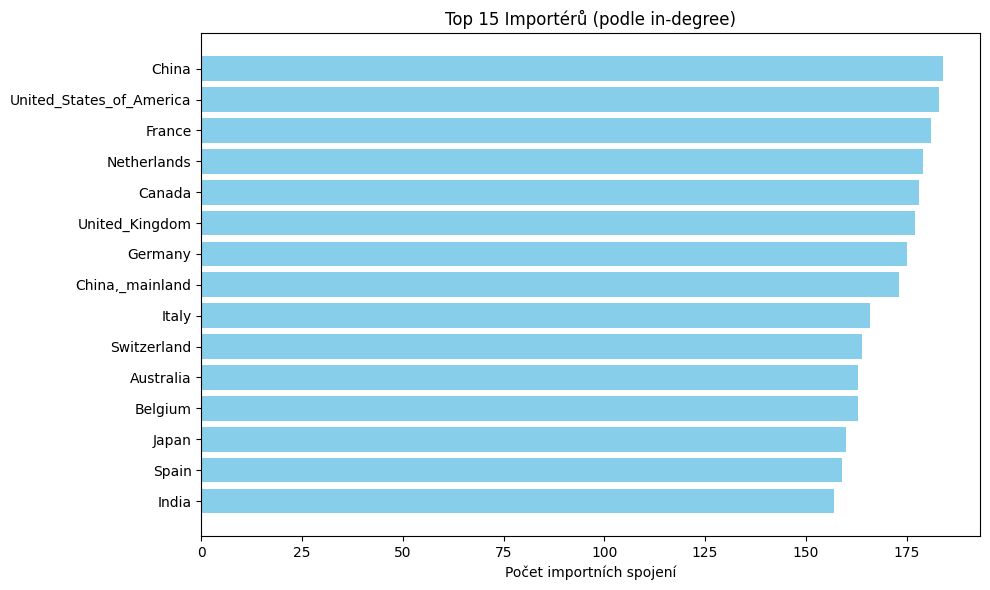

In [188]:
# Calculate in-degree (number of incoming edges) for each node in the weighted projection
in_degrees = dict(G_weighted.in_degree())

# Get top 15 importers by in-degree
top_importers = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:15]

# Prepare labels and values
labels = [node_id_to_label[node_id] for node_id, _ in top_importers]
values = [deg for _, deg in top_importers]

plt.figure(figsize=(10, 6))
plt.barh(labels[::-1], values[::-1], color='skyblue')
plt.xlabel('Počet importních spojení')
plt.title('Top 15 Importérů (podle in-degree)')
plt.tight_layout()
plt.savefig(PLOT_DIR / "top_15_importers.png", dpi=300)
plt.show()

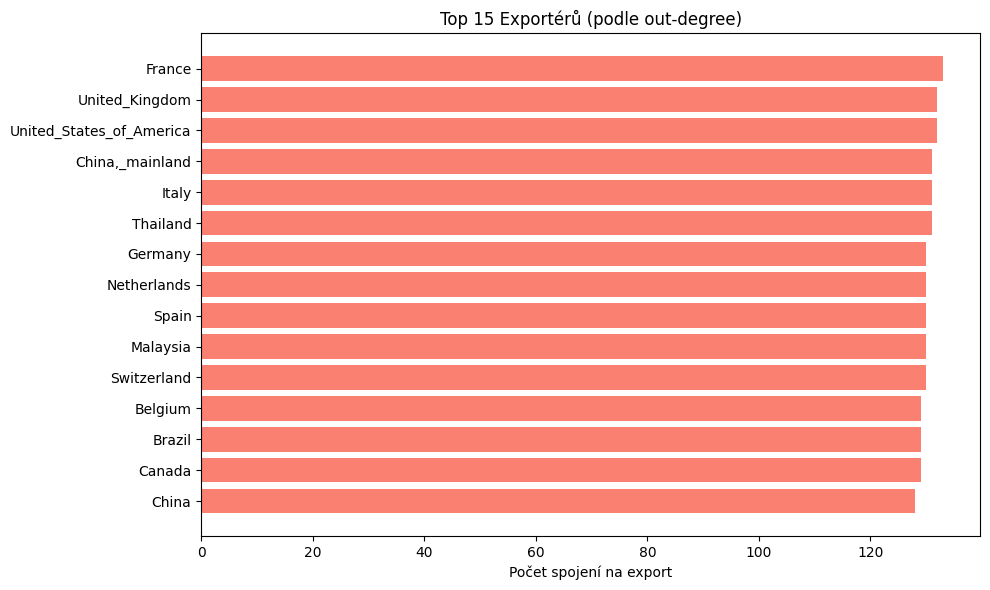

In [189]:
# Calculate out-degree (number of outgoing edges) for each node in the weighted projection
out_degrees = dict(G_weighted.out_degree())

top_exporters = sorted(out_degrees.items(), key=lambda x: x[1], reverse=True)[:15]

# Prepare labels and values
exporter_labels = [node_id_to_label[node_id] for node_id, _ in top_exporters]
exporter_values = [deg for _, deg in top_exporters]

plt.figure(figsize=(10, 6))
plt.barh(exporter_labels[::-1], exporter_values[::-1], color='salmon')
plt.xlabel('Počet spojení na export')
plt.title('Top 15 Exportérů (podle out-degree)')
plt.tight_layout()
plt.savefig(PLOT_DIR / "top_15_exporters.png", dpi=300)
plt.show()

### Porovnání export vs import

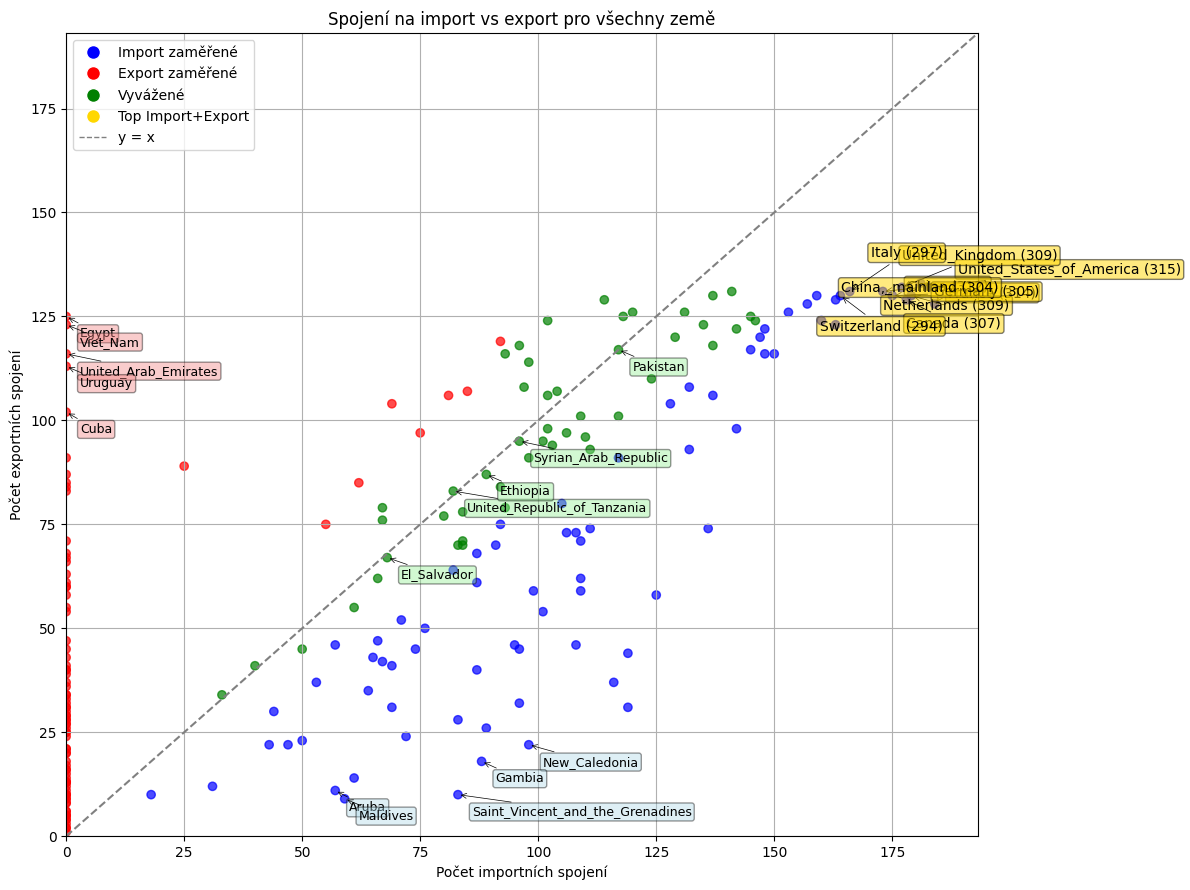

In [190]:
# Improved annotation: spread labels in top-right quadrant to avoid overlap

import_totals = dict(G_weighted.in_degree())
export_totals = dict(G_weighted.out_degree())

countries = [node_id_to_label[node_id] for node_id in import_totals.keys()]
imports = np.array([import_totals[node_id] for node_id in import_totals.keys()])
exports = np.array([export_totals[node_id] for node_id in export_totals.keys()])

ratio = (imports + 1) / (exports + 1)
colors = np.where(ratio > 1.2, 'blue', np.where(ratio < 0.8, 'red', 'green'))

plt.figure(figsize=(12, 9))
sc = plt.scatter(imports, exports, c=colors, alpha=0.7, label='Countries')
plt.plot([0, max(imports.max(), exports.max()) * 1.05],
         [0, max(imports.max(), exports.max()) * 1.05],
         color='gray', linestyle='--', label='y = x')

plt.xlabel('Počet importních spojení')
plt.ylabel('Počet exportních spojení')
plt.title('Spojení na import vs export pro všechny země')
plt.grid(True)

# Score = imports + exports, annotate top 10 in top-right quadrant (high import & export)
score = imports + exports
top_right_mask = (imports > np.percentile(imports, 80)) & (exports > np.percentile(exports, 80))
top_right_idx = np.where(top_right_mask)[0]
top_right_scores = score[top_right_idx]
sorted_idx = top_right_idx[np.argsort(-top_right_scores)][:10]

# Use different offsets for each label to reduce overlap
offsets = [(20, 10), (20, -10), (-20, 10), (-20, -10), (0, 20), (0, -20), (30, 0), (-30, 0), (15, 25), (-15, -25)]
for i, idx in enumerate(sorted_idx):
    plt.annotate(
        f"{countries[idx]} ({score[idx]})",
        (imports[idx], exports[idx]), # type: ignore
        fontsize=10,
        xytext=offsets[i % len(offsets)],
        textcoords='offset points',
        bbox=dict(boxstyle="round,pad=0.2", fc="gold", alpha=0.5),
        arrowprops=dict(arrowstyle="->", color='black', lw=0.5)
    )

# Also annotate top 5 import-heavy, export-heavy, balanced countries for context
top_import_idx = np.argsort(ratio)[-5:]
top_export_idx = np.argsort(ratio)[:5]
balanced_idx = np.argsort(np.abs(ratio - 1))[:5]

def annotate_idx(idx_list, color):
    for idx in idx_list:
        plt.annotate(
            countries[idx],
            (imports[idx], exports[idx]), # type: ignore
            fontsize=9,
            xytext=(10, -15),
            textcoords='offset points',
            bbox=dict(boxstyle="round,pad=0.2", fc=color, alpha=0.4),
            arrowprops=dict(arrowstyle="->", color='black', lw=0.5)
        )

annotate_idx(top_import_idx, "lightblue")
annotate_idx(top_export_idx, "lightcoral")
annotate_idx(balanced_idx, "lightgreen")

plt.xlim(0, max(imports.max(), exports.max()) * 1.05)
plt.ylim(0, max(imports.max(), exports.max()) * 1.05)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Import zaměřené', markerfacecolor='blue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Export zaměřené', markerfacecolor='red', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Vyvážené', markerfacecolor='green', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Top Import+Export', markerfacecolor='gold', markersize=10),
    Line2D([0], [0], color='gray', lw=1, linestyle='--', label='y = x')
]
plt.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig(PLOT_DIR / "import_vs_export_scatter.png", dpi=300)
plt.show()

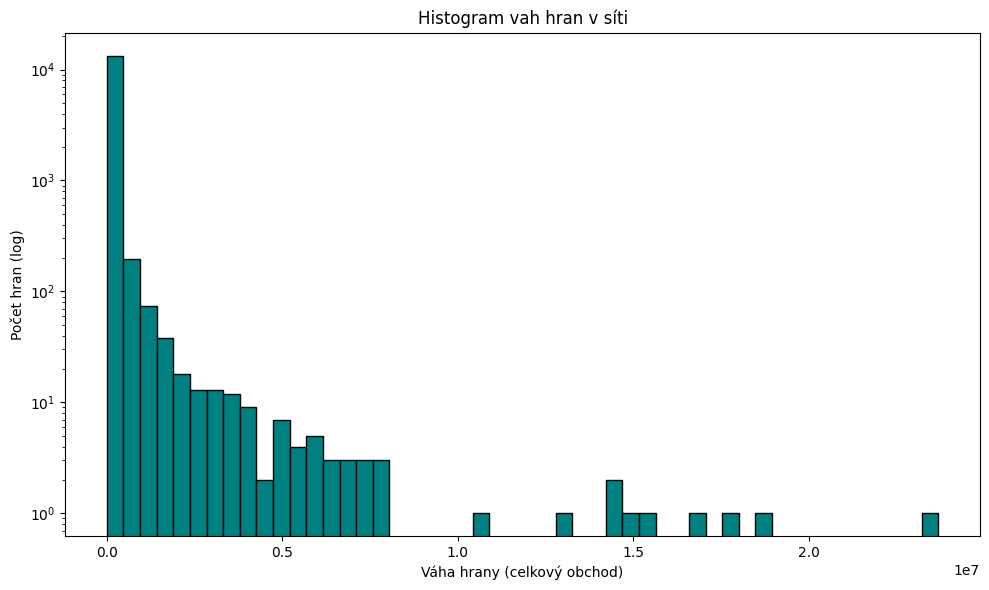

In [191]:
# Histogram of edge weights
weights = [d['weight'] for _, _, d in G_weighted.edges(data=True)]
plt.figure(figsize=(10, 6))
plt.hist(weights, bins=50, color='teal', edgecolor='black', log=True)
plt.xlabel('Váha hrany (celkový obchod)')
plt.ylabel('Počet hran (log)')
plt.title('Histogram vah hran v síti')
plt.tight_layout()
plt.savefig(PLOT_DIR / "edge_weight_histogram.png", dpi=300)
plt.show()

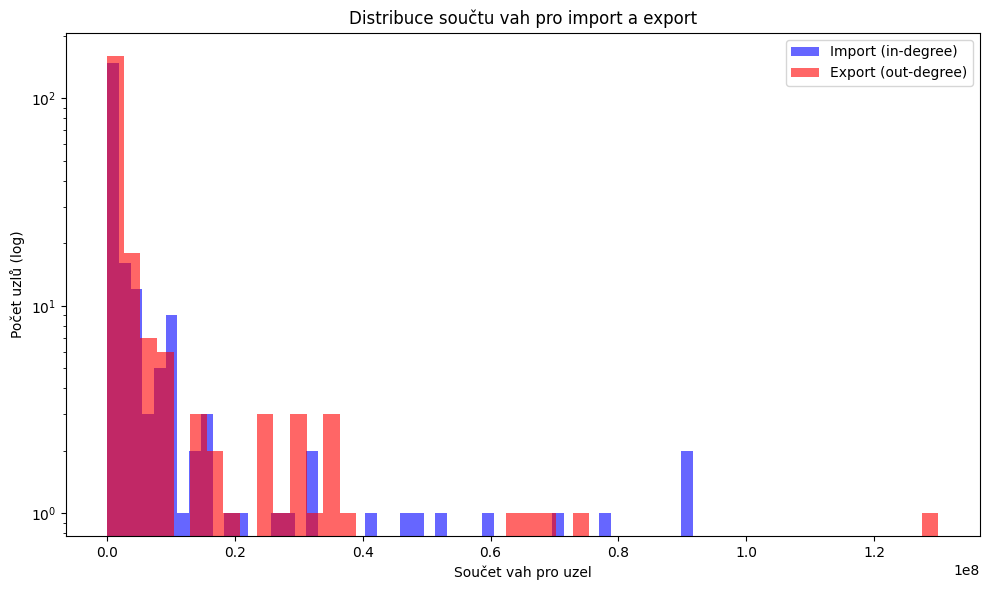

In [192]:
# Weighted degree (sum of weights for each node)
weighted_in = dict(G_weighted.in_degree(weight='weight'))
weighted_out = dict(G_weighted.out_degree(weight='weight'))

plt.figure(figsize=(10, 6))
plt.hist(list(weighted_in.values()), bins=50, alpha=0.6, label='Import (in-degree)', color='blue', log=True)
plt.hist(list(weighted_out.values()), bins=50, alpha=0.6, label='Export (out-degree)', color='red', log=True)
plt.xlabel('Součet vah pro uzel')
plt.ylabel('Počet uzlů (log)')
plt.title('Distribuce součtu vah pro import a export')
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "weighted_degree_distribution.png", dpi=300)
plt.show()

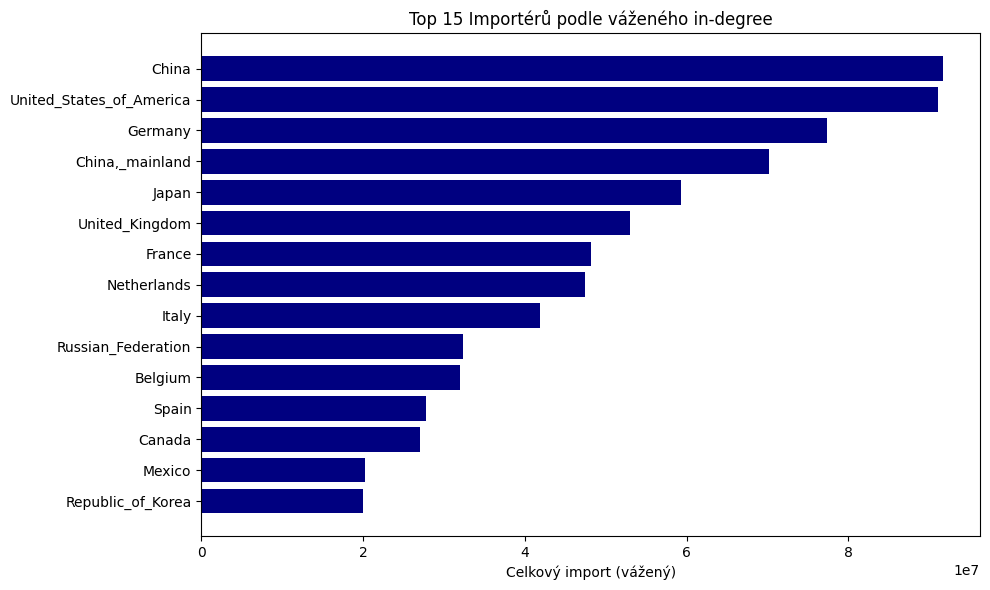

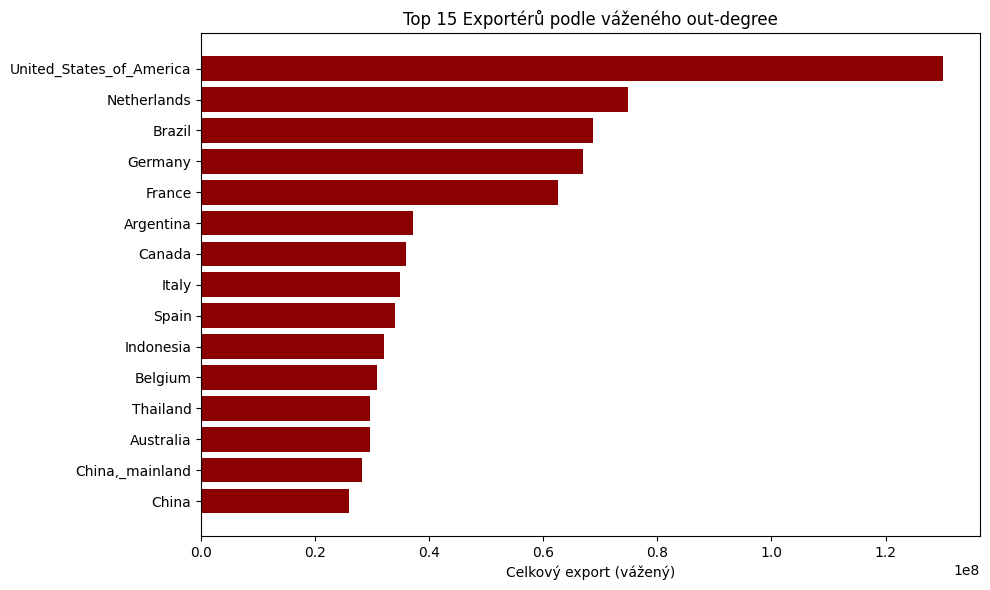

In [193]:
# Top 15 importers/exporters by weighted degree
top_importers_w = sorted(weighted_in.items(), key=lambda x: x[1], reverse=True)[:15]
top_exporters_w = sorted(weighted_out.items(), key=lambda x: x[1], reverse=True)[:15]

labels_import = [node_id_to_label[n] for n, _ in top_importers_w]
values_import = [v for _, v in top_importers_w]
labels_export = [node_id_to_label[n] for n, _ in top_exporters_w]
values_export = [v for _, v in top_exporters_w]

plt.figure(figsize=(10, 6))
plt.barh(labels_import[::-1], values_import[::-1], color='navy')
plt.xlabel('Celkový import (vážený)')
plt.title('Top 15 Importérů podle váženého in-degree')
plt.tight_layout()
plt.savefig(PLOT_DIR / "top_15_weighted_importers.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
plt.barh(labels_export[::-1], values_export[::-1], color='darkred')
plt.xlabel('Celkový export (vážený)')
plt.title('Top 15 Exportérů podle váženého out-degree')
plt.tight_layout()
plt.savefig(PLOT_DIR / "top_15_weighted_exporters.png", dpi=300)
plt.show()

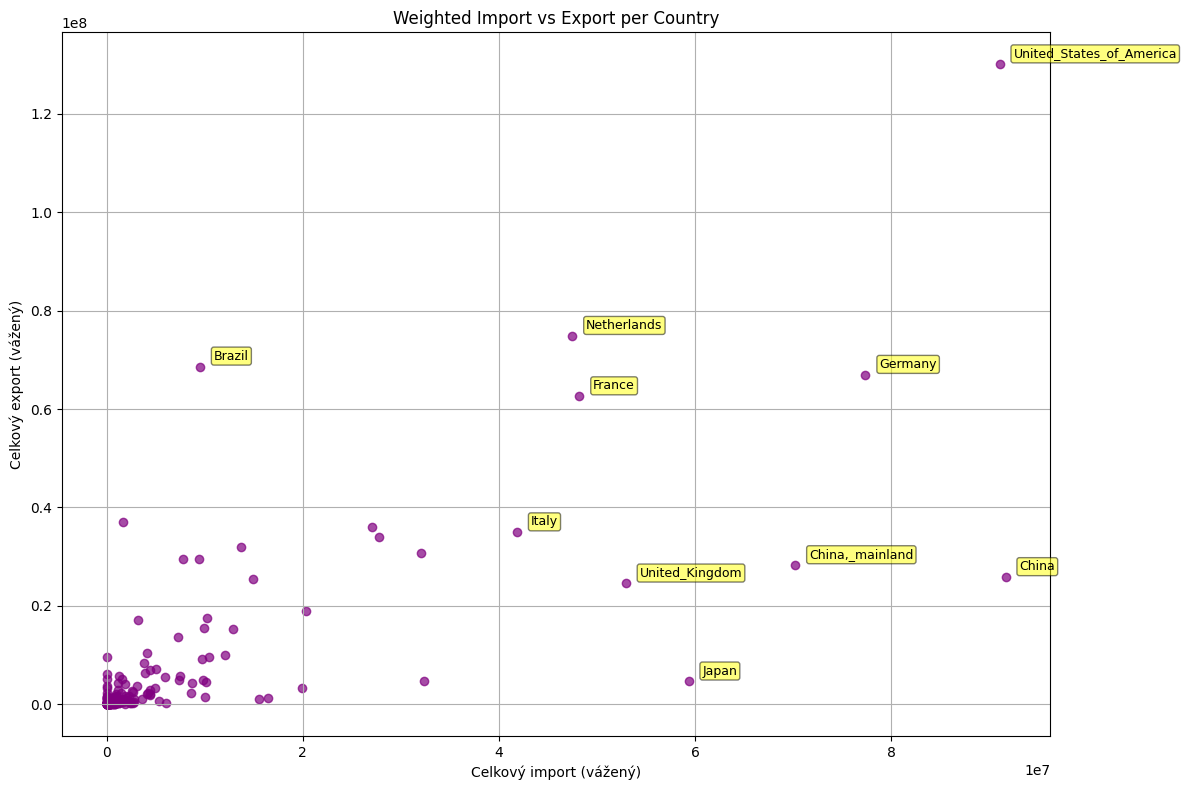

In [194]:
# Scatter plot of weighted import vs export per country
weighted_imports = np.array([weighted_in[n] for n in weighted_in.keys()])
weighted_exports = np.array([weighted_out[n] for n in weighted_out.keys()])
country_labels = [node_id_to_label[n] for n in weighted_in.keys()]

plt.figure(figsize=(12, 8))
plt.scatter(weighted_imports, weighted_exports, alpha=0.7, color='purple')
plt.xlabel('Celkový import (vážený)')
plt.ylabel('Celkový export (vážený)')
plt.title('Weighted Import vs Export per Country')
plt.grid(True)

# Annotate top 10 by total trade (import + export)
total_trade = weighted_imports + weighted_exports
top_idx = np.argsort(-total_trade)[:10]
for idx in top_idx:
    plt.annotate(country_labels[idx], (weighted_imports[idx], weighted_exports[idx]), # type: ignore
                 fontsize=9, xytext=(10, 5), textcoords='offset points',
                 bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.5))

plt.tight_layout()
plt.savefig(PLOT_DIR / "weighted_import_vs_export_scatter.png", dpi=300)
plt.show()

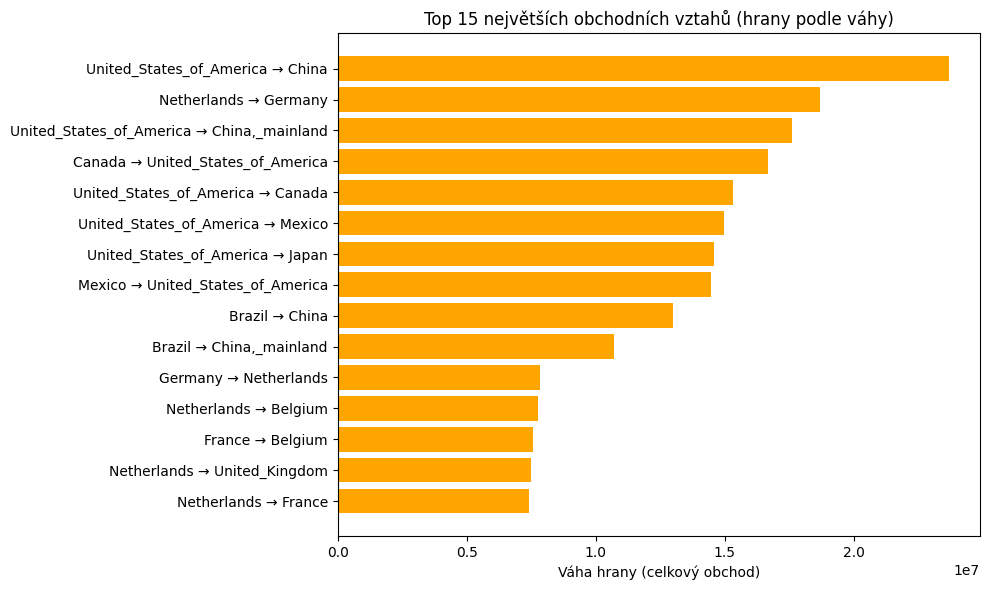

In [195]:
# Sort all edges by weight in descending order
all_edges = [(row['source'], row['target'], {'weight': row['weight']}) for _, row in weighted_edges.iterrows()]
top_15_edges = sorted(all_edges, key=lambda x: x[2]['weight'], reverse=True)[:15]

# Prepare labels and values for plotting
edge_labels = [f"{node_id_to_label[source]} → {node_id_to_label[target]}" for source, target, data in top_15_edges]
edge_weights = [data['weight'] for _, _, data in top_15_edges]

plt.figure(figsize=(10, 6))
plt.barh(edge_labels[::-1], edge_weights[::-1], color='orange')
plt.xlabel('Váha hrany (celkový obchod)')
plt.title('Top 15 největších obchodních vztahů (hrany podle váhy)')
plt.tight_layout()
plt.show()

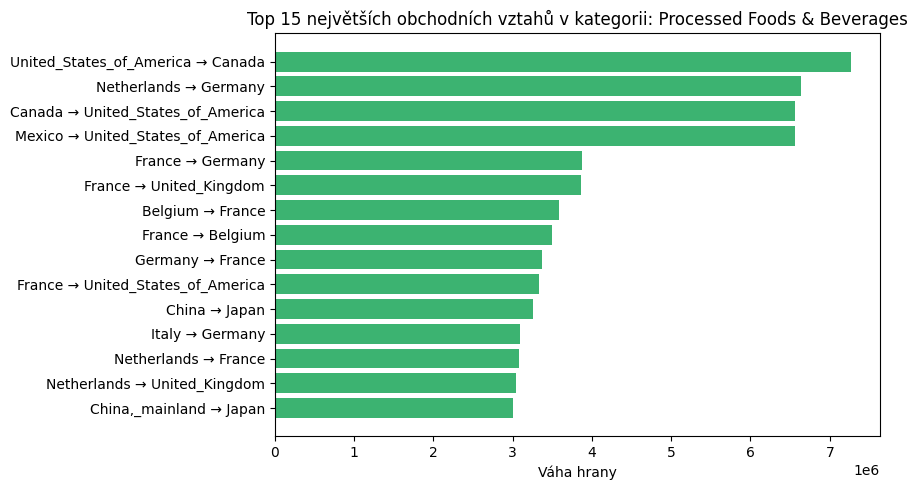

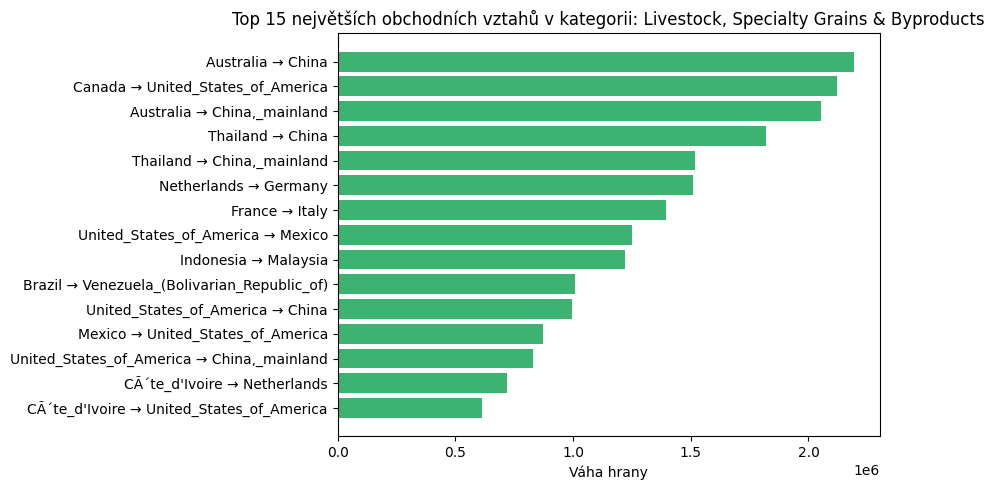

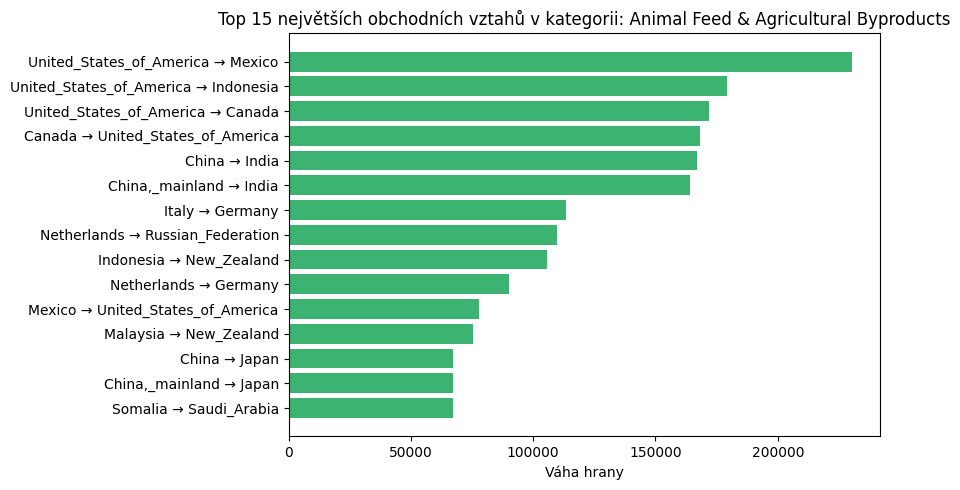

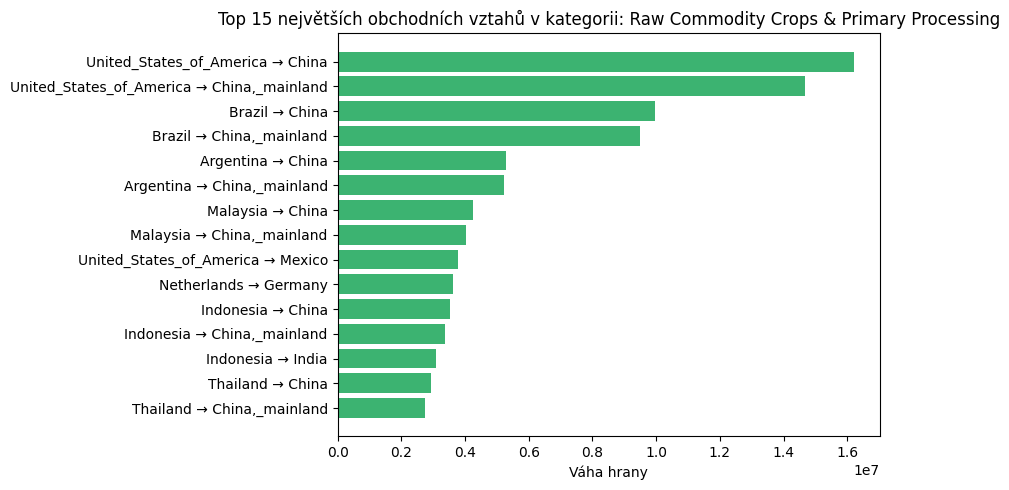

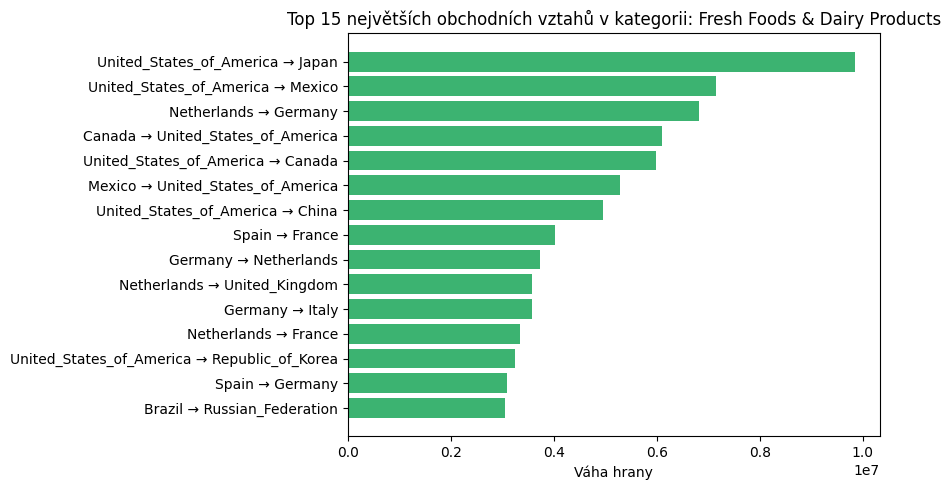

In [196]:
# Top 10 edges by weight for each Jaccard category (cluster)
for cluster_id in sorted(layers_df['jaccard_cluster'].unique()):
    # Get all layers in this cluster
    cluster_layers = layers_df[layers_df['jaccard_cluster'] == cluster_id]['layerID']
    cluster_label = layers_df[layers_df['jaccard_cluster'] == cluster_id]['cluster_name'].iloc[0] \
        if 'cluster_name' in layers_df.columns else f'Cluster {cluster_id}'
    
    # Filter edges for this cluster
    cluster_edges = edges_df[edges_df['layerID'].isin(cluster_layers)]
    
    # Aggregate weights for each edge (source, target) in the cluster
    agg_edges = cluster_edges.groupby(['source', 'target'])['weight'].sum().reset_index()
    
    # Get top 15 edges by weight
    top_edges = agg_edges.sort_values('weight', ascending=False).head(15)
    edge_labels = [f"{node_id_to_label[src]} → {node_id_to_label[tgt]}" for src, tgt in zip(top_edges['source'], top_edges['target'])]
    edge_weights = top_edges['weight']
    
    plt.figure(figsize=(9, 5))
    plt.barh(edge_labels[::-1], edge_weights[::-1], color='mediumseagreen')
    plt.xlabel('Váha hrany')
    plt.title(f'Top 15 největších obchodních vztahů v kategorii: {cluster_label}')
    plt.tight_layout()
    plt.show()


Processed Foods & Beverages (Jaccard Cluster 0):
  Nodes: 214, Edges: 11412
  Mean in-degree: 53.33, Median in-degree: 60.00
  Mean out-degree: 53.33, Median out-degree: 41.00
  Isolated nodes: 0
  Top importers: ['United_States_of_America', 'China', 'France', 'Canada', 'Netherlands', 'Australia', 'China,_mainland', 'Germany', 'United_Kingdom', 'Japan']
  Top exporters: ['France', 'United_Kingdom', 'United_States_of_America', 'China,_mainland', 'Germany', 'Italy', 'Spain', 'Thailand', 'Belgium', 'Netherlands']


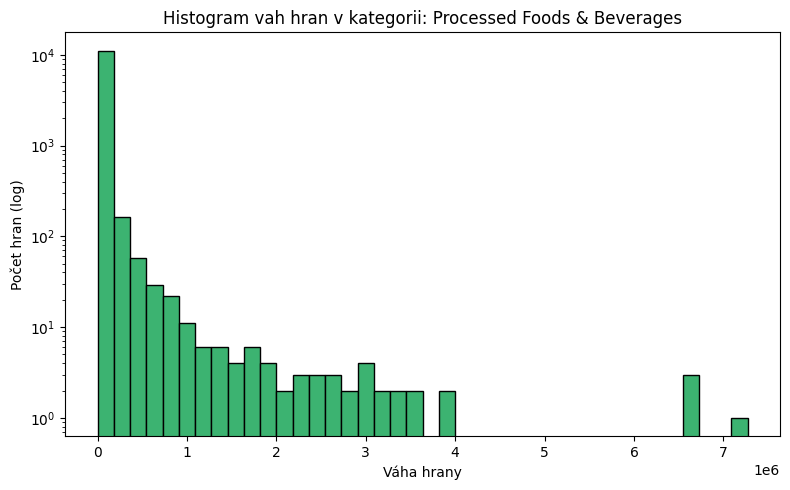

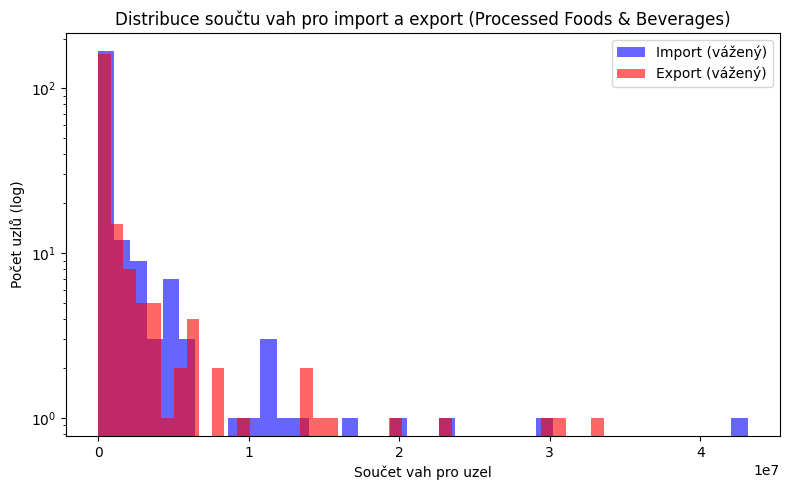

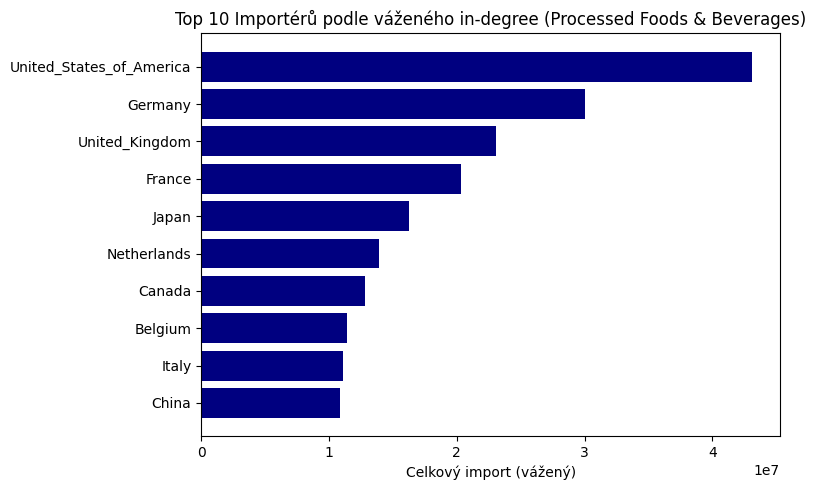

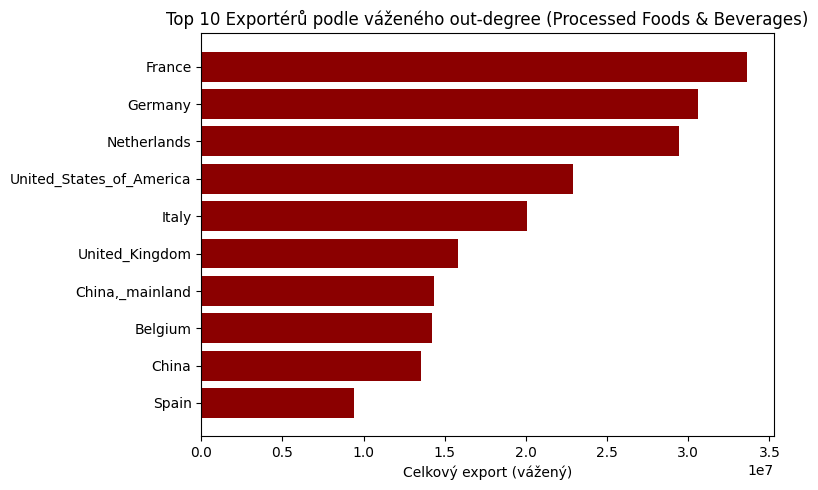

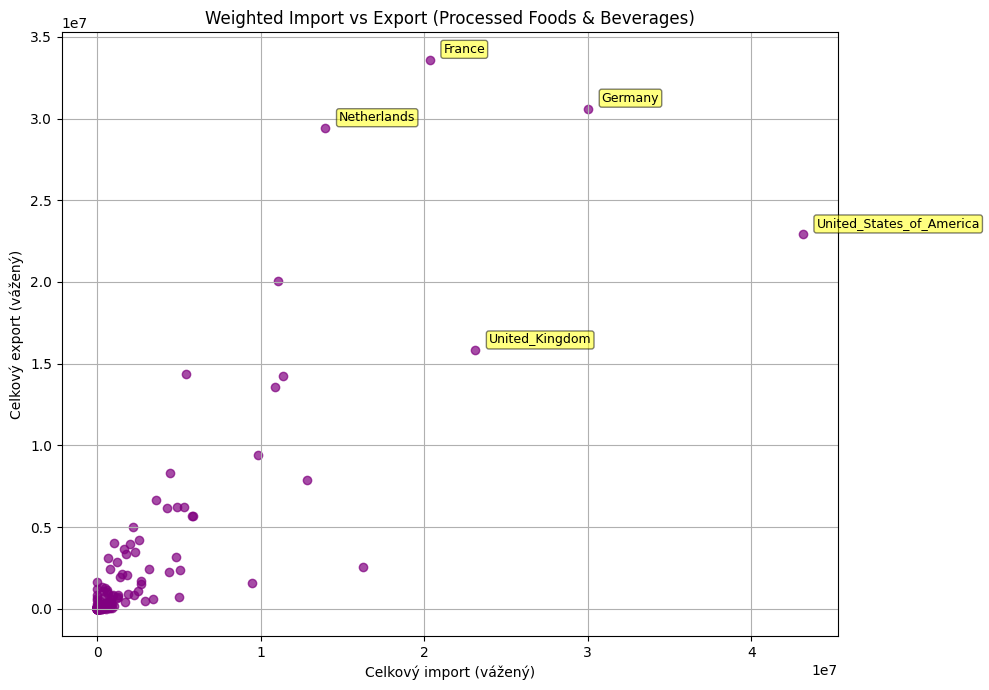


Livestock, Specialty Grains & Byproducts (Jaccard Cluster 1):
  Nodes: 193, Edges: 4548
  Mean in-degree: 23.56, Median in-degree: 15.00
  Mean out-degree: 23.56, Median out-degree: 13.00
  Isolated nodes: 0
  Top importers: ['Netherlands', 'France', 'United_States_of_America', 'Belgium', 'Germany', 'United_Kingdom', 'Canada', 'India', 'Italy', 'China']
  Top exporters: ['United_States_of_America', 'France', 'Netherlands', 'China', 'China,_mainland', 'Germany', 'Canada', 'Spain', 'Italy', 'Belgium']


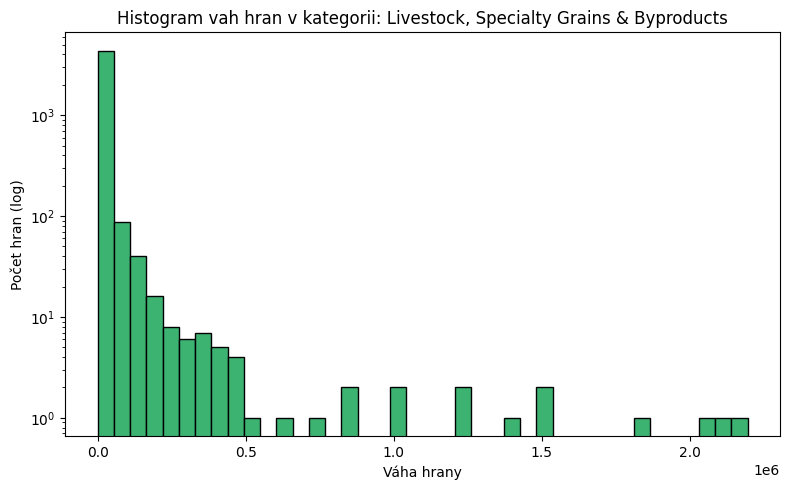

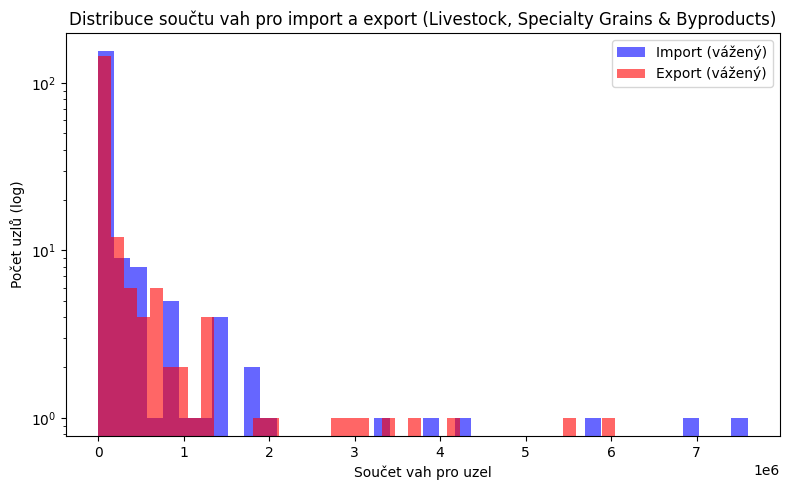

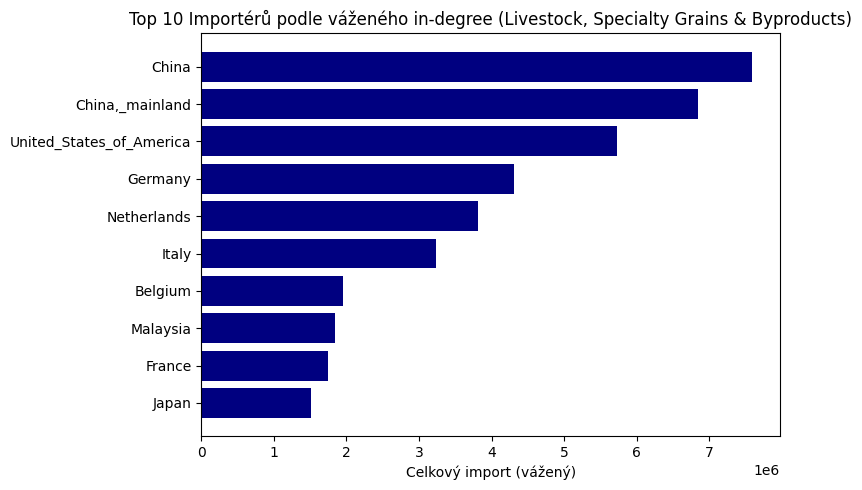

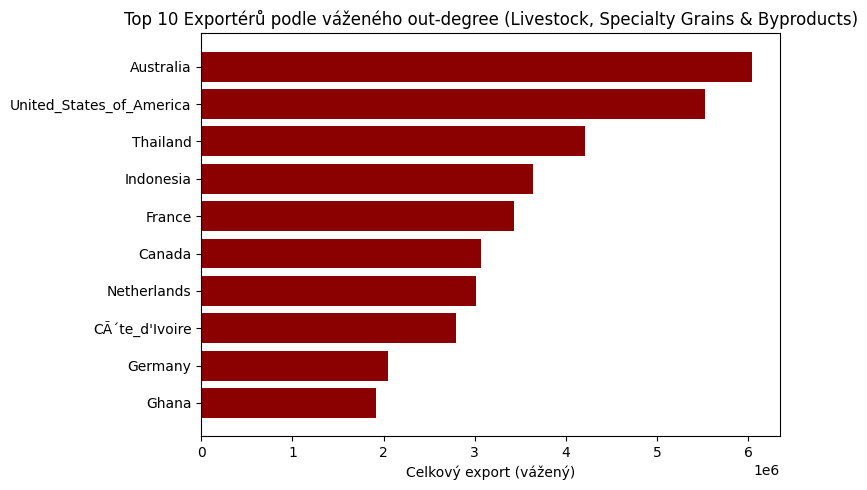

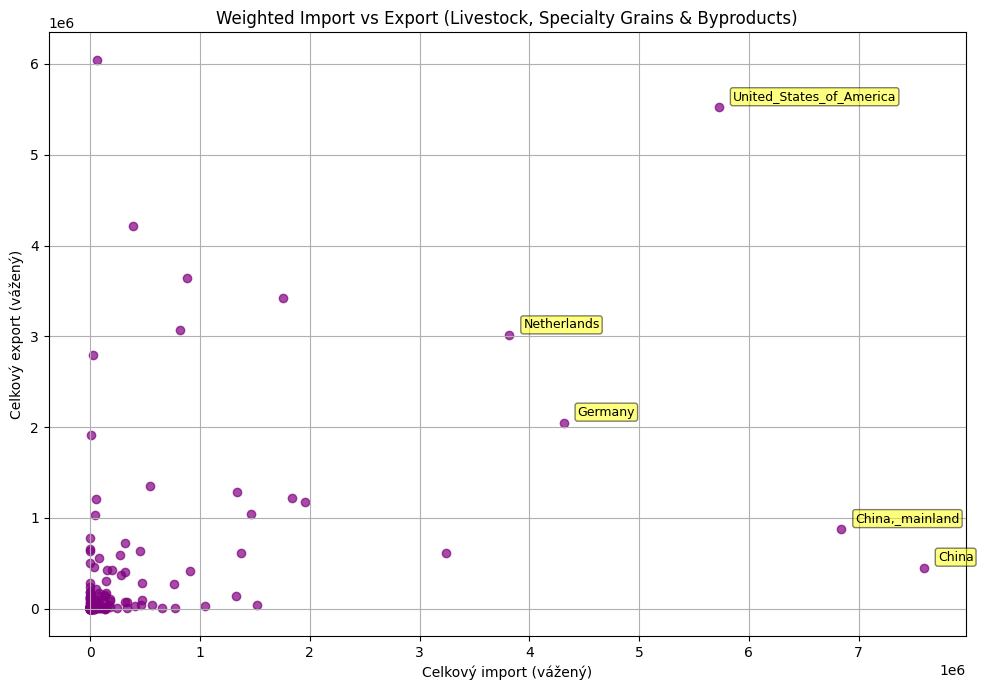


Animal Feed & Agricultural Byproducts (Jaccard Cluster 2):
  Nodes: 184, Edges: 2795
  Mean in-degree: 15.19, Median in-degree: 7.00
  Mean out-degree: 15.19, Median out-degree: 8.00
  Isolated nodes: 0
  Top importers: ['China', 'India', 'Italy', 'United_States_of_America', 'Pakistan', 'Thailand', 'Switzerland', 'China,_mainland', 'Turkey', 'Germany']
  Top exporters: ['Italy', 'United_States_of_America', 'France', 'China', 'China,_mainland', 'Netherlands', 'Germany', 'United_Kingdom', 'Belgium', 'Spain']


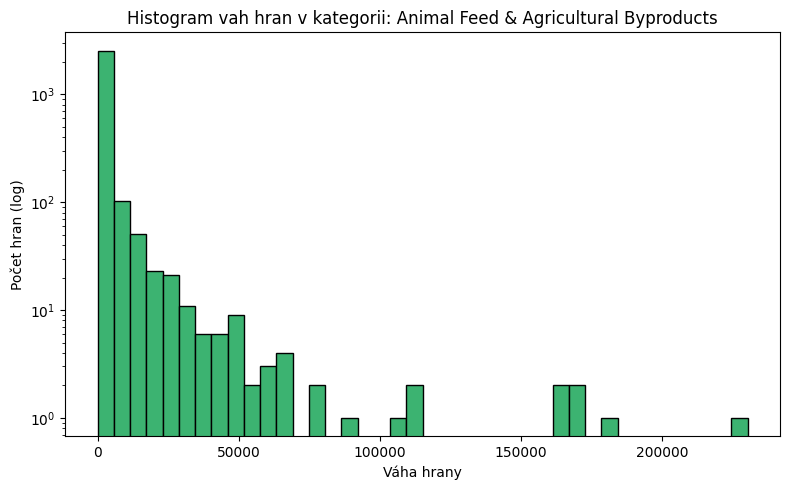

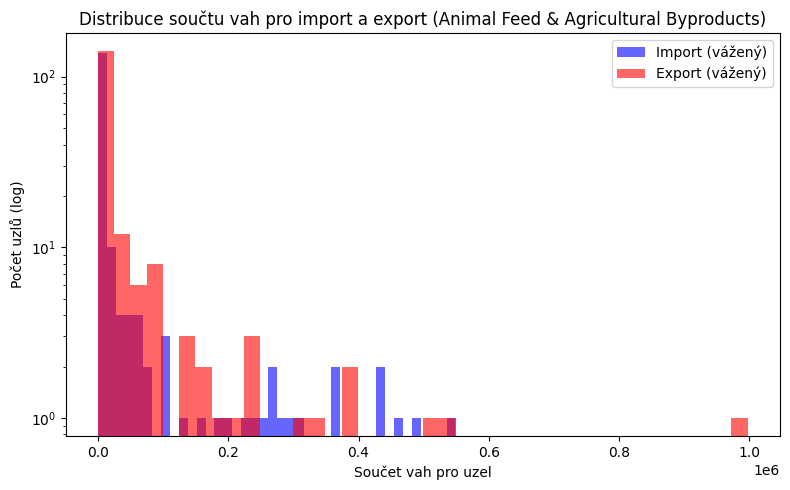

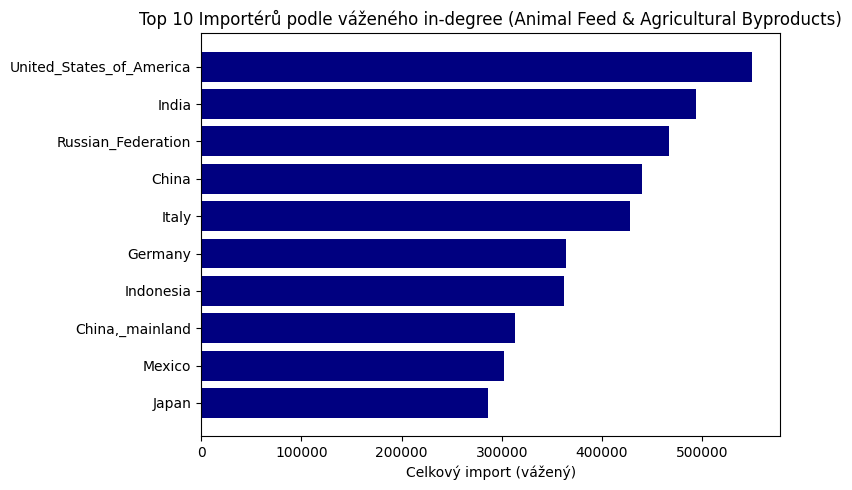

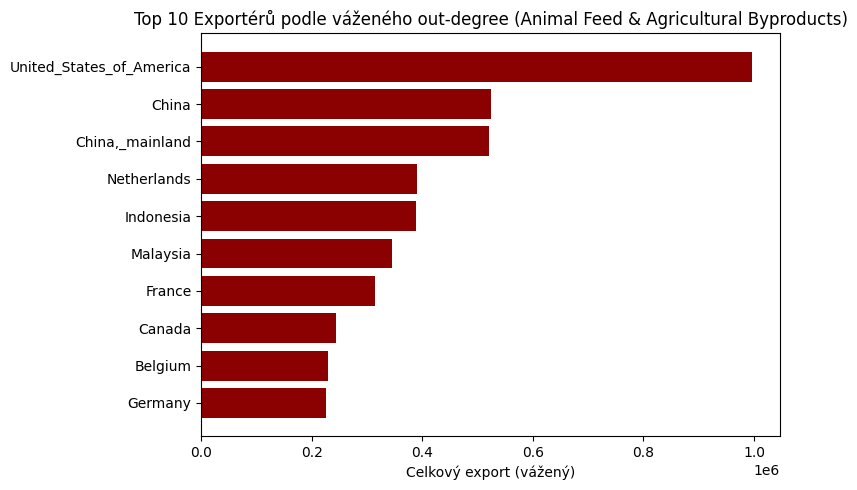

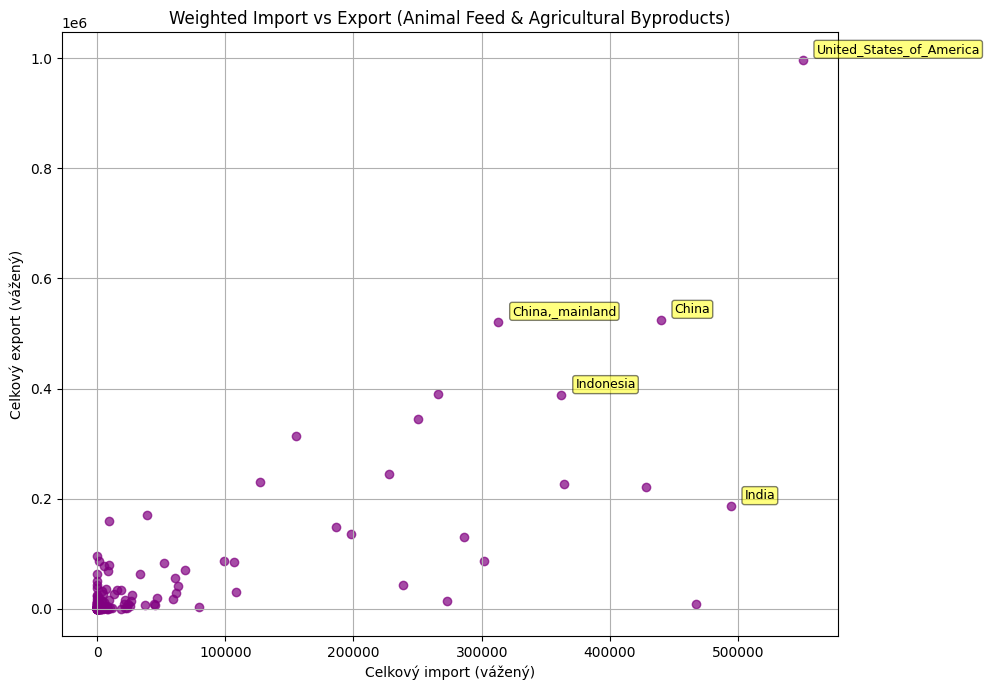


Raw Commodity Crops & Primary Processing (Jaccard Cluster 3):
  Nodes: 206, Edges: 9245
  Mean in-degree: 44.88, Median in-degree: 38.50
  Mean out-degree: 44.88, Median out-degree: 35.00
  Isolated nodes: 0
  Top importers: ['France', 'Germany', 'Netherlands', 'United_States_of_America', 'United_Kingdom', 'Italy', 'Belgium', 'Canada', 'China', 'Switzerland']
  Top exporters: ['China,_mainland', 'Thailand', 'China', 'United_States_of_America', 'Indonesia', 'Italy', 'India', 'Brazil', 'Netherlands', 'Germany']


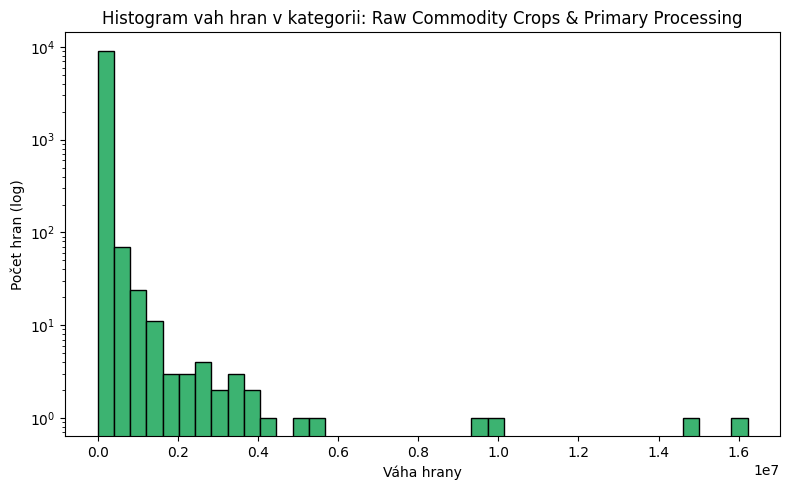

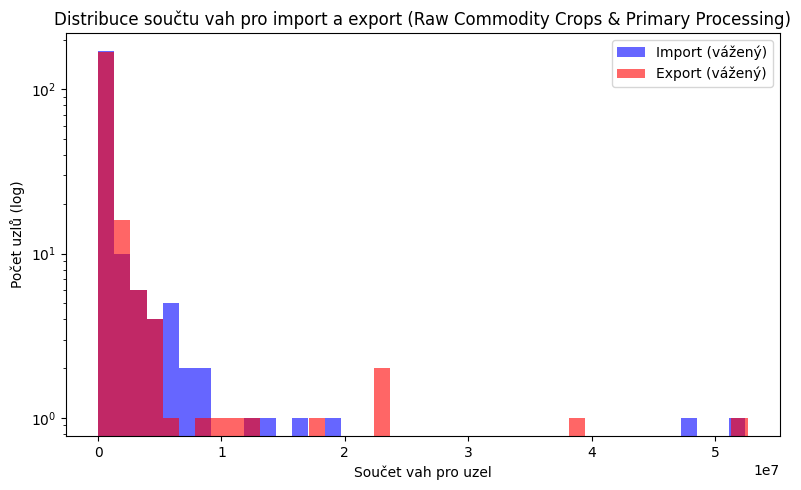

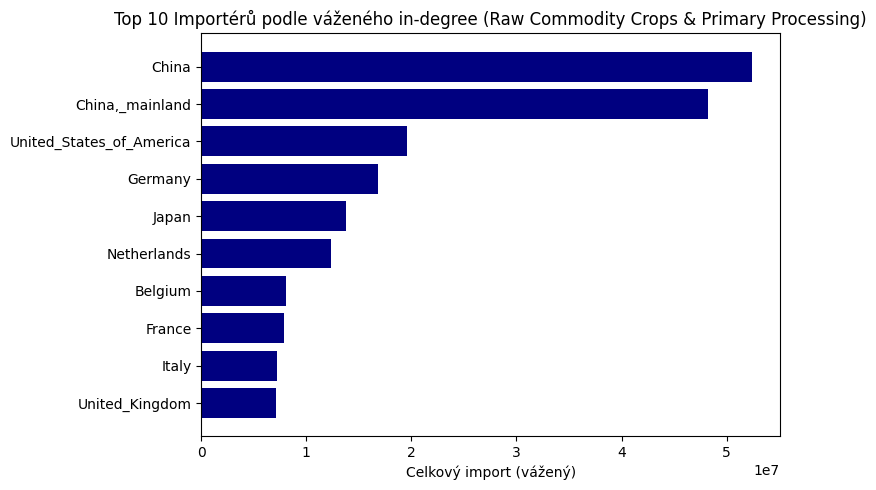

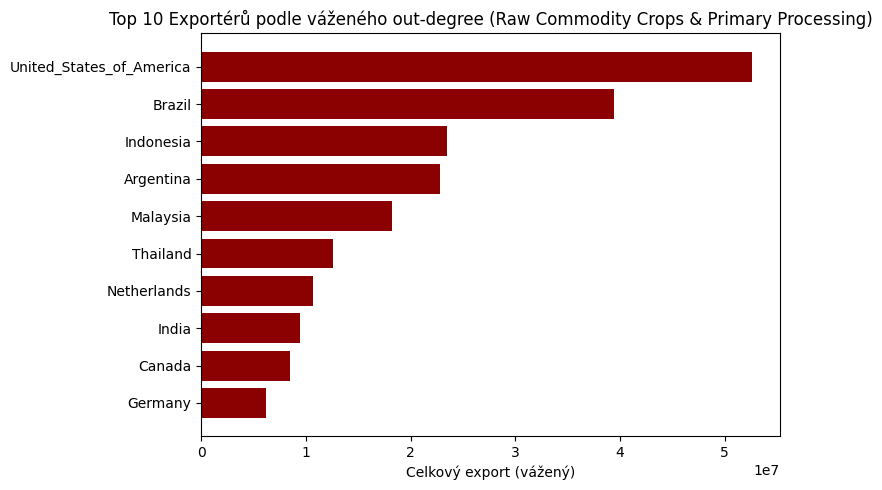

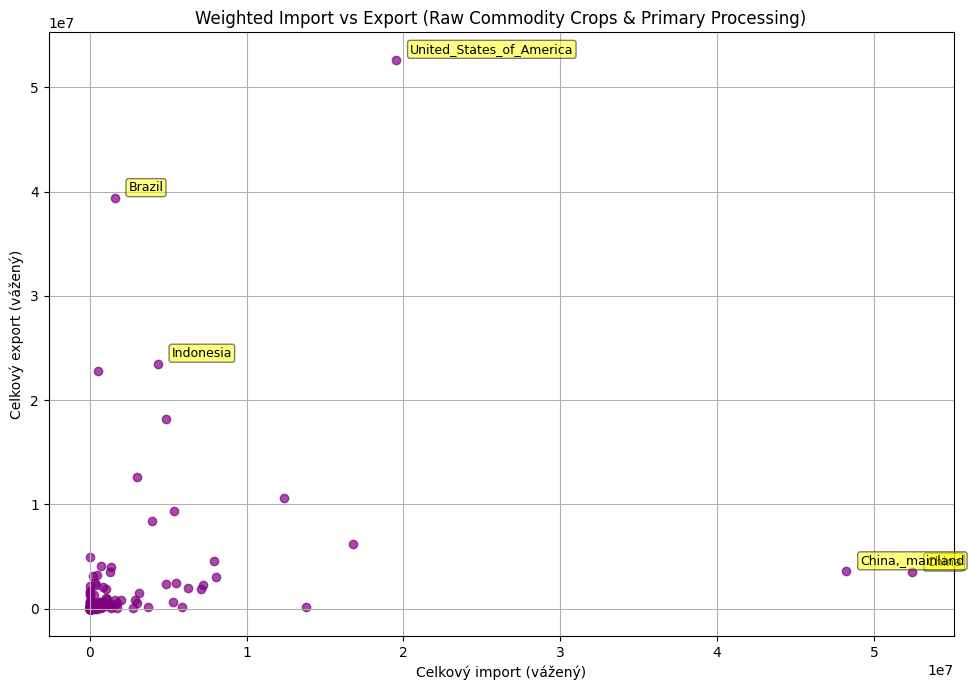


Fresh Foods & Dairy Products (Jaccard Cluster 4):
  Nodes: 209, Edges: 8870
  Mean in-degree: 42.44, Median in-degree: 46.00
  Mean out-degree: 42.44, Median out-degree: 29.00
  Isolated nodes: 0
  Top importers: ['United_Kingdom', 'Canada', 'France', 'United_States_of_America', 'Netherlands', 'Italy', 'Belgium', 'Germany', 'Switzerland', 'China']
  Top exporters: ['United_States_of_America', 'China,_mainland', 'Thailand', 'France', 'Italy', 'Netherlands', 'China', 'Germany', 'Canada', 'United_Kingdom']


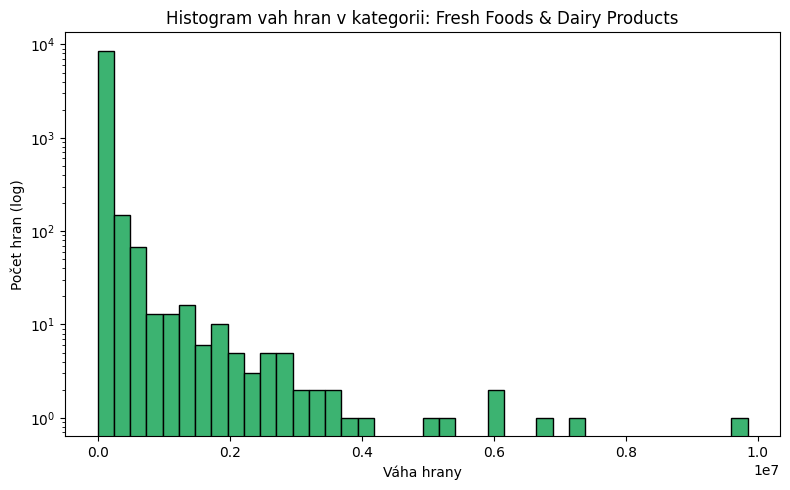

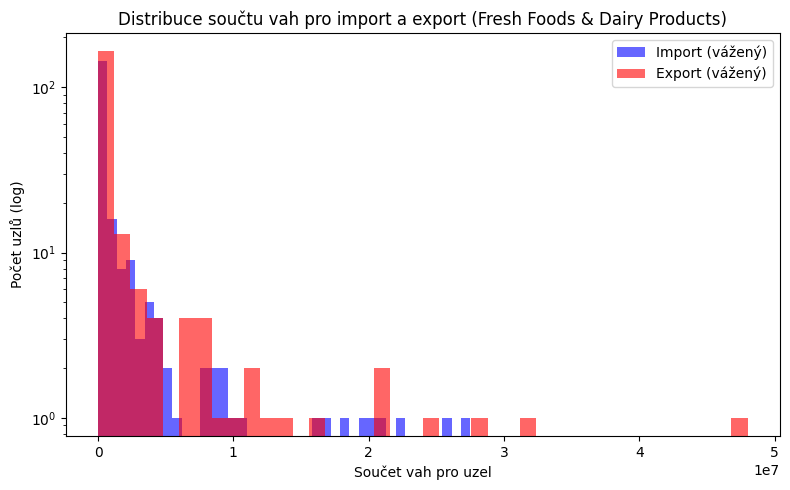

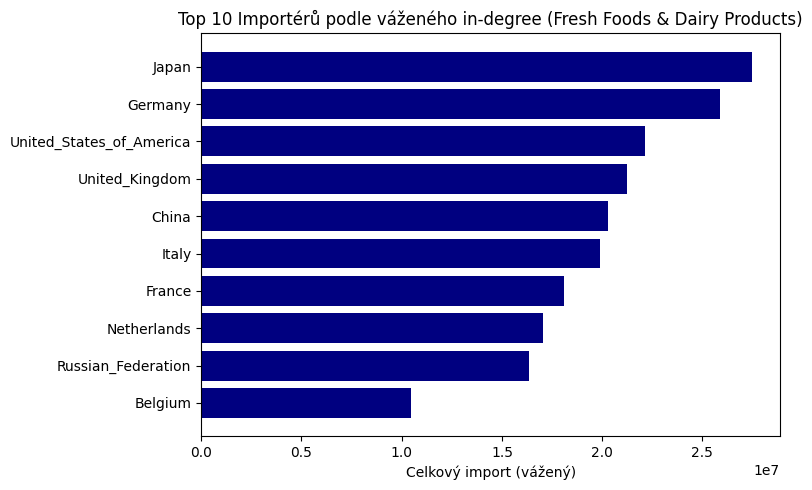

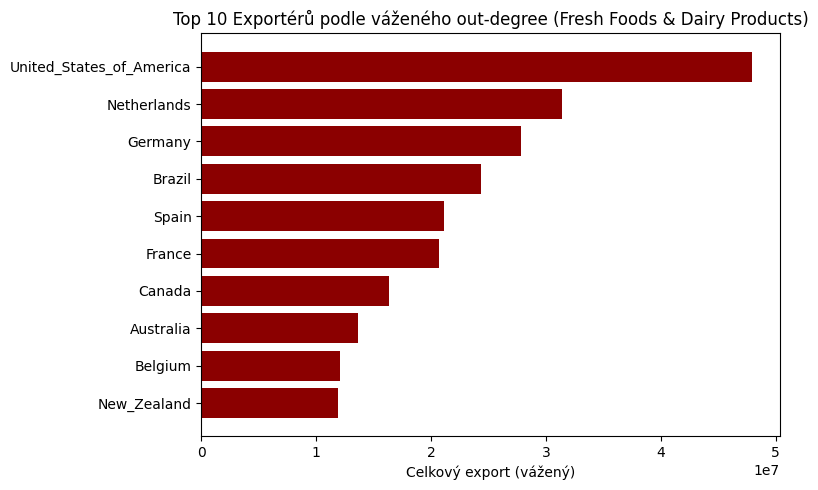

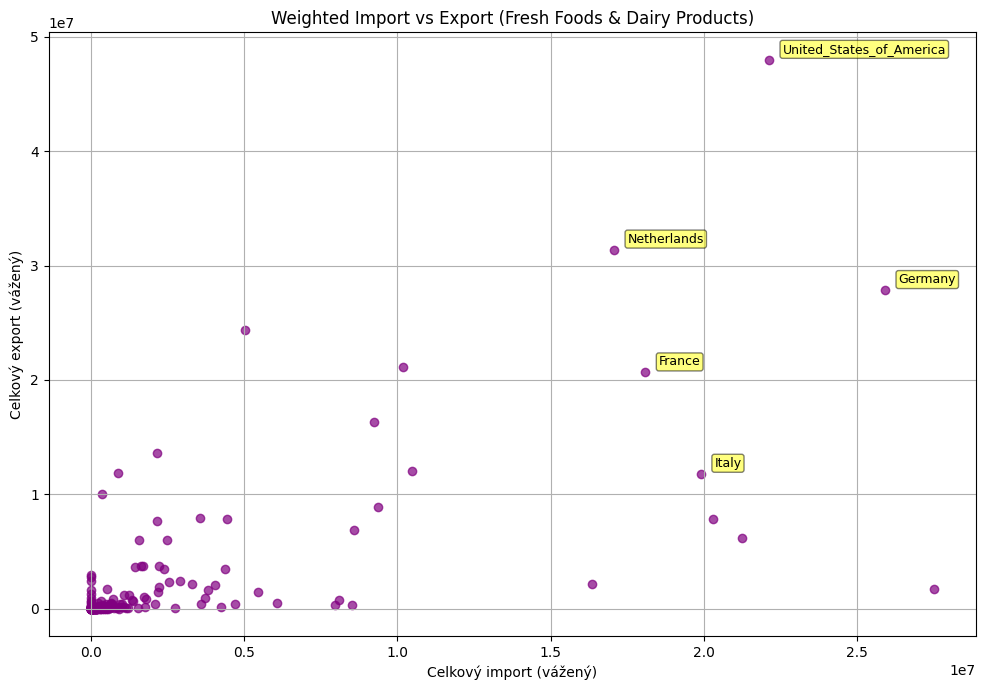

In [197]:
for cluster_id in sorted(category_graphs_weighted.keys()):
    G_cat = category_graphs_weighted[cluster_id]
    cluster_label = layers_df[layers_df['jaccard_cluster'] == cluster_id]['cluster_name'].iloc[0] \
        if 'cluster_name' in layers_df.columns else f'Cluster {cluster_id}'

    # Degree statistics
    in_deg = [deg for _, deg in G_cat.in_degree()]
    out_deg = [deg for _, deg in G_cat.out_degree()]
    total_deg = [deg for _, deg in G_cat.degree()]
    print(f"\n{cluster_label} (Jaccard Cluster {cluster_id}):")
    print(f"  Nodes: {G_cat.number_of_nodes()}, Edges: {G_cat.number_of_edges()}")
    print(f"  Mean in-degree: {np.mean(in_deg):.2f}, Median in-degree: {np.median(in_deg):.2f}")
    print(f"  Mean out-degree: {np.mean(out_deg):.2f}, Median out-degree: {np.median(out_deg):.2f}")
    print(f"  Isolated nodes: {(np.array(total_deg) == 0).sum()}")

    # Top importers/exporters
    top_importers = sorted(G_cat.in_degree(), key=lambda x: x[1], reverse=True)[:10]
    top_exporters = sorted(G_cat.out_degree(), key=lambda x: x[1], reverse=True)[:10]
    print("  Top importers:", [node_id_to_label[n] for n, _ in top_importers])
    print("  Top exporters:", [node_id_to_label[n] for n, _ in top_exporters])

    # Histogram of edge weights
    weights = [d['weight'] for _, _, d in G_cat.edges(data=True)]
    plt.figure(figsize=(8, 5))
    plt.hist(weights, bins=40, color='mediumseagreen', edgecolor='black', log=True)
    plt.xlabel('Váha hrany')
    plt.ylabel('Počet hran (log)')
    plt.title(f'Histogram vah hran v kategorii: {cluster_label}')
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"edge_weight_histogram_cluster_{cluster_id}.png", dpi=300)
    plt.show()

    # Weighted degree distribution
    weighted_in = dict(G_cat.in_degree(weight='weight'))
    weighted_out = dict(G_cat.out_degree(weight='weight'))
    plt.figure(figsize=(8, 5))
    plt.hist(list(weighted_in.values()), bins=40, alpha=0.6, label='Import (vážený)', color='blue', log=True)
    plt.hist(list(weighted_out.values()), bins=40, alpha=0.6, label='Export (vážený)', color='red', log=True)
    plt.xlabel('Součet vah pro uzel')
    plt.ylabel('Počet uzlů (log)')
    plt.title(f'Distribuce součtu vah pro import a export ({cluster_label})')
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"weighted_degree_distribution_cluster_{cluster_id}.png", dpi=300)
    plt.show()

    # Top weighted importers/exporters
    top_importers_w = sorted(weighted_in.items(), key=lambda x: x[1], reverse=True)[:10]
    top_exporters_w = sorted(weighted_out.items(), key=lambda x: x[1], reverse=True)[:10]
    labels_import = [node_id_to_label[n] for n, _ in top_importers_w]
    values_import = [v for _, v in top_importers_w]
    labels_export = [node_id_to_label[n] for n, _ in top_exporters_w]
    values_export = [v for _, v in top_exporters_w]
    plt.figure(figsize=(8, 5))
    plt.barh(labels_import[::-1], values_import[::-1], color='navy')
    plt.xlabel('Celkový import (vážený)')
    plt.title(f'Top 10 Importérů podle váženého in-degree ({cluster_label})')
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"top_weighted_importers_cluster_{cluster_id}.png", dpi=300)
    plt.show()
    plt.figure(figsize=(8, 5))
    plt.barh(labels_export[::-1], values_export[::-1], color='darkred')
    plt.xlabel('Celkový export (vážený)')
    plt.title(f'Top 10 Exportérů podle váženého out-degree ({cluster_label})')
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"top_weighted_exporters_cluster_{cluster_id}.png", dpi=300)
    plt.show()

    # Scatter plot weighted import vs export
    weighted_imports = np.array(list(weighted_in.values()))
    weighted_exports = np.array(list(weighted_out.values()))
    country_labels = [node_id_to_label[n] for n in weighted_in.keys()]
    plt.figure(figsize=(10, 7))
    plt.scatter(weighted_imports, weighted_exports, alpha=0.7, color='purple')
    plt.xlabel('Celkový import (vážený)')
    plt.ylabel('Celkový export (vážený)')
    plt.title(f'Weighted Import vs Export ({cluster_label})')
    plt.grid(True)
    total_trade = weighted_imports + weighted_exports
    top_idx = np.argsort(-total_trade)[:5]
    for idx in top_idx:
        plt.annotate(country_labels[idx], (weighted_imports[idx], weighted_exports[idx]),  # type: ignore
                     fontsize=9, xytext=(10, 5), textcoords='offset points',
                     bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.5))
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"weighted_import_vs_export_scatter_cluster_{cluster_id}.png", dpi=300)
    plt.show()

In [198]:
# for cluster_id, G_cat in category_graphs_weighted.items():
#     cluster_label = layers_df[layers_df['jaccard_cluster'] == cluster_id]['cluster_name'].iloc[0] \
#         if 'cluster_name' in layers_df.columns else f'Cluster {cluster_id}'

#     # Create an unweighted version of the graph (remove weights)
#     G_unweighted_cat = nx.DiGraph()
#     G_unweighted_cat.add_nodes_from(G_cat.nodes(data=True))
#     G_unweighted_cat.add_edges_from(G_cat.edges())

#     plt.figure(figsize=(16, 14))

#     n = G_unweighted_cat.number_of_nodes()
#     optimal_k = 1 / np.sqrt(n) * 5
#     pos = nx.spring_layout(G_unweighted_cat, k=optimal_k, iterations=100, seed=42)

#     node_labels = {n: node_id_to_label.get(n, str(n)) for n in G_unweighted_cat.nodes()}
#     nx.draw_networkx_nodes(G_unweighted_cat, pos, node_size=60, node_color='skyblue', alpha=0.8)
#     nx.draw_networkx_edges(G_unweighted_cat, pos, alpha=0.3, arrowsize=10)
#     nx.draw_networkx_labels(G_unweighted_cat, pos, labels=node_labels, font_size=7)

#     plt.title(f"Unweighted síť pro kategorii: {cluster_label}")
#     plt.axis('off')
#     plt.tight_layout()
#     plt.savefig(PLOT_DIR / f"network_plot_unweighted_cluster_{cluster_id}.png", dpi=300)
#     plt.show()

## Komunity

### Distribuce modularity podle velikosti kombinace kategorií vrstev pomocí violin plotu

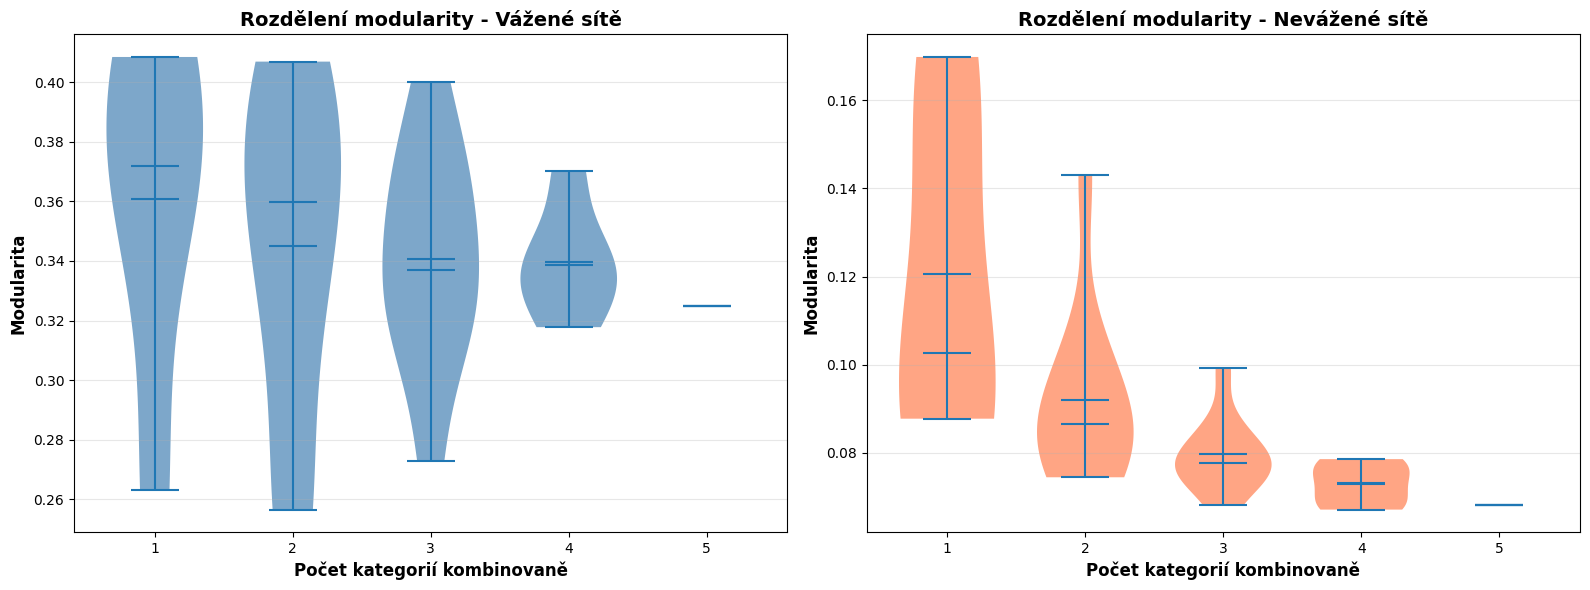

In [199]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Prepare data for violin plots
combo_sizes = sorted(df_weighted_combos['combo_size'].unique())

# Weighted
data_w = [df_weighted_combos[df_weighted_combos['combo_size'] == size]['modularity'].values 
          for size in combo_sizes]
parts_w = ax1.violinplot(data_w, positions=combo_sizes, widths=0.7, 
                          showmeans=True, showmedians=True)
for pc in parts_w['bodies']:
    pc.set_facecolor('steelblue')
    pc.set_alpha(0.7)
ax1.set_xlabel('Počet kategorií kombinovaně', fontsize=12, weight='bold')
ax1.set_ylabel('Modularita', fontsize=12, weight='bold')
ax1.set_title('Rozdělení modularity - Vážené sítě', fontsize=14, weight='bold')
ax1.set_xticks(combo_sizes)
ax1.grid(axis='y', alpha=0.3)

# Unweighted
data_uw = [df_unweighted_combos[df_unweighted_combos['combo_size'] == size]['modularity'].values 
           for size in combo_sizes]
parts_uw = ax2.violinplot(data_uw, positions=combo_sizes, widths=0.7, 
                           showmeans=True, showmedians=True)
for pc in parts_uw['bodies']:
    pc.set_facecolor('coral')
    pc.set_alpha(0.7)
ax2.set_xlabel('Počet kategorií kombinovaně', fontsize=12, weight='bold')
ax2.set_ylabel('Modularita', fontsize=12, weight='bold')
ax2.set_title('Rozdělení modularity - Nevážené sítě', fontsize=14, weight='bold')
ax2.set_xticks(combo_sizes)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(COMMUNITY_DIR / "modularity_violin_plot.png", dpi=300, bbox_inches='tight')
plt.show()

### 15 nejlepších vs 15 nejhorších kombinací podle rozdílu modularity mezi váženou a neváženou sítí

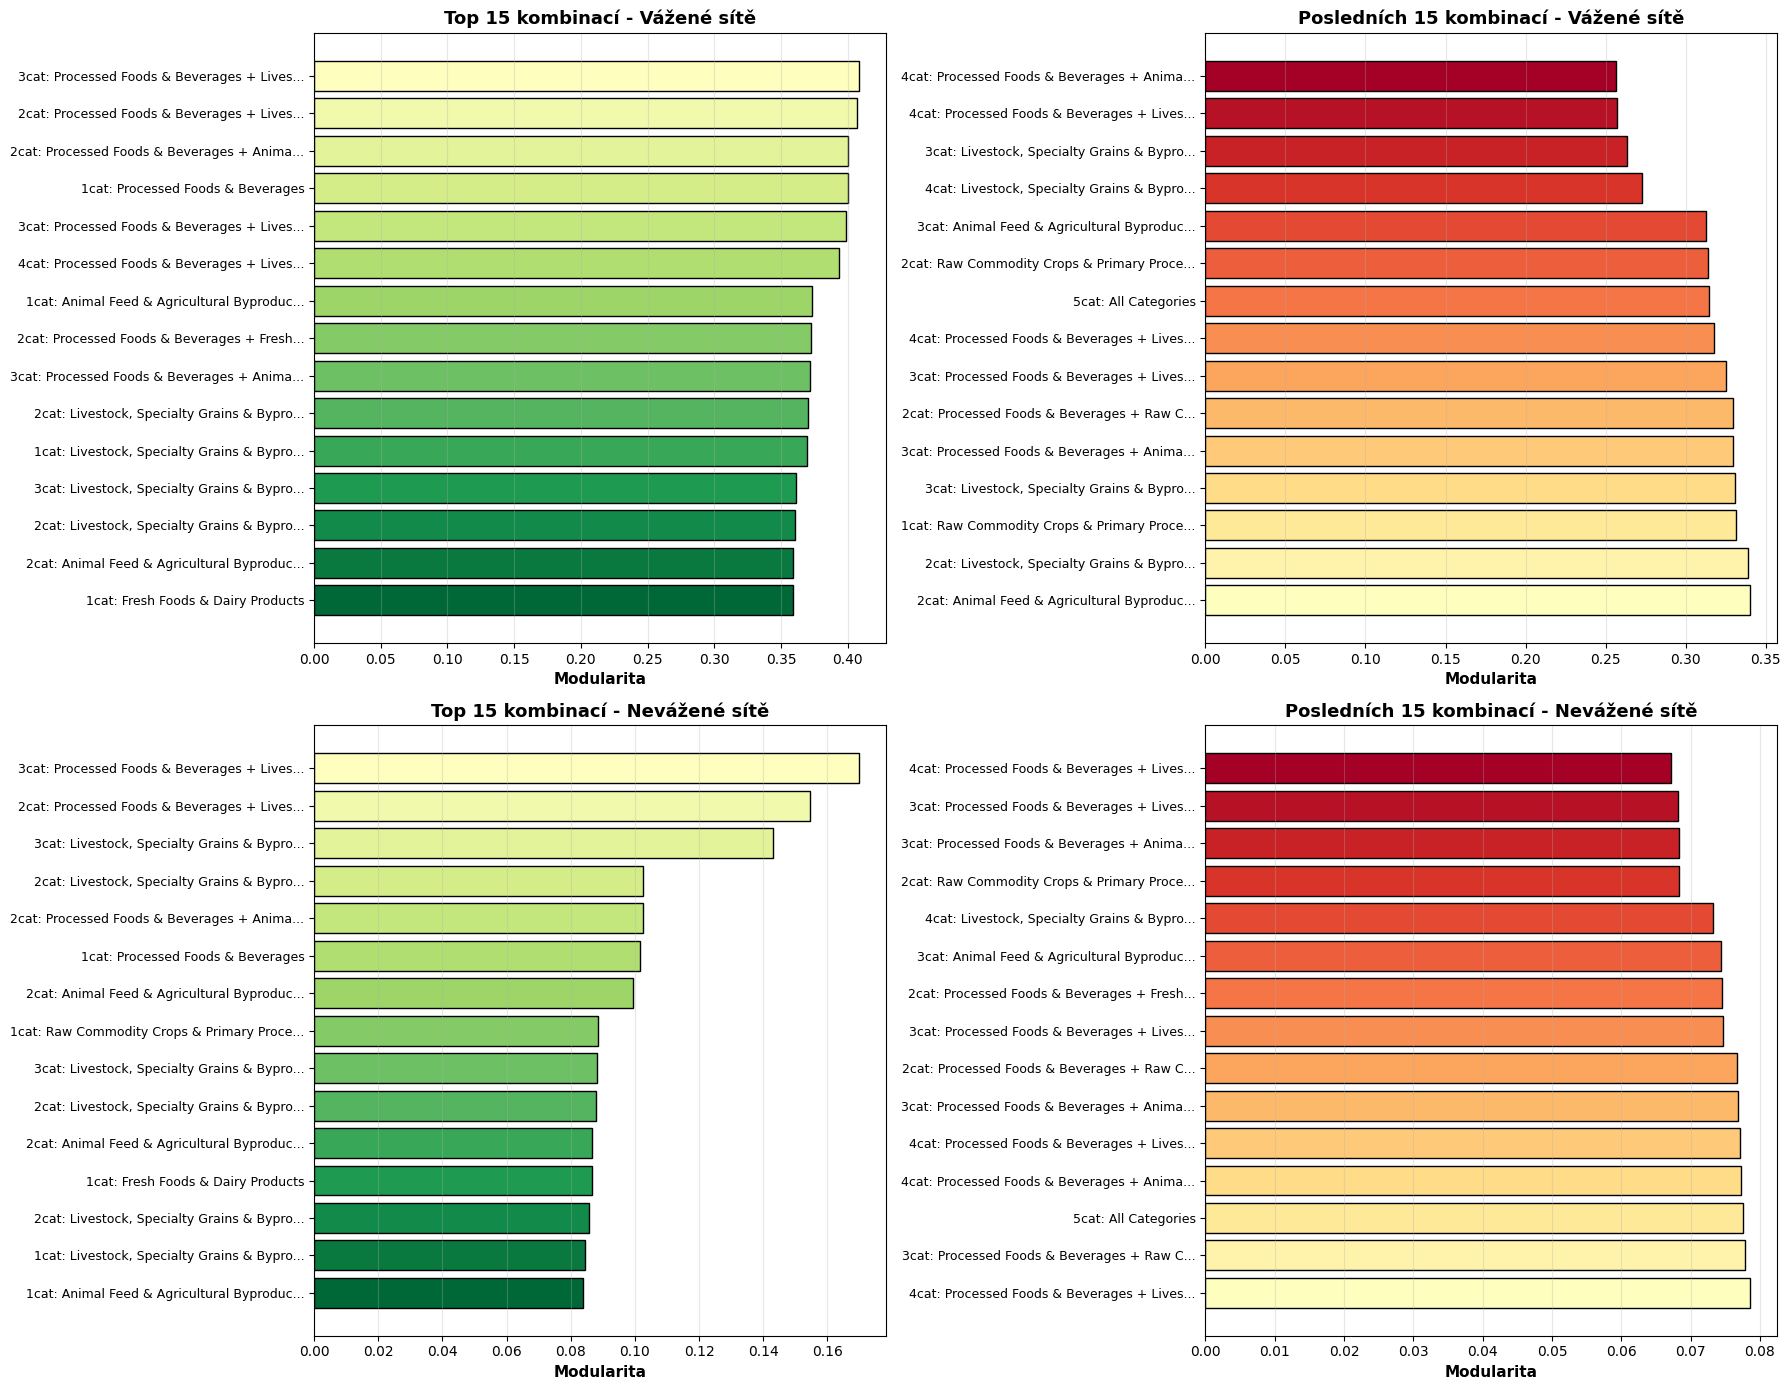

In [200]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

# Top 15 Weighted
top_15_w = df_weighted_combos.nlargest(15, 'modularity')
labels_w = [f"{row['combo_size']}cat: {row['category_names'][:35]}..." if len(row['category_names']) > 35 
            else f"{row['combo_size']}cat: {row['category_names']}" 
            for _, row in top_15_w.iterrows()]
colors_w = plt.cm.RdYlGn(np.linspace(0.5, 1, len(top_15_w))) # type: ignore
ax1.barh(range(len(top_15_w)), top_15_w['modularity'].values, color=colors_w, edgecolor='black')
ax1.set_yticks(range(len(top_15_w)))
ax1.set_yticklabels(labels_w[::-1], fontsize=9)
ax1.set_xlabel('Modularita', fontsize=11, weight='bold')
ax1.set_title('Top 15 kombinací - Vážené sítě', fontsize=13, weight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

# Bottom 15 Weighted
bottom_15_w = df_weighted_combos.nsmallest(15, 'modularity')
labels_w_bottom = [f"{row['combo_size']}cat: {row['category_names'][:35]}..." if len(row['category_names']) > 35 
                   else f"{row['combo_size']}cat: {row['category_names']}" 
                   for _, row in bottom_15_w.iterrows()]
colors_w_bottom = plt.cm.RdYlGn(np.linspace(0, 0.5, len(bottom_15_w))) # type: ignore
ax2.barh(range(len(bottom_15_w)), bottom_15_w['modularity'].values, color=colors_w_bottom, edgecolor='black')
ax2.set_yticks(range(len(bottom_15_w)))
ax2.set_yticklabels(labels_w_bottom[::-1], fontsize=9)
ax2.set_xlabel('Modularita', fontsize=11, weight='bold')
ax2.set_title('Posledních 15 kombinací - Vážené sítě', fontsize=13, weight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

# Top 15 Unweighted
top_15_uw = df_unweighted_combos.nlargest(15, 'modularity')
labels_uw = [f"{row['combo_size']}cat: {row['category_names'][:35]}..." if len(row['category_names']) > 35 
             else f"{row['combo_size']}cat: {row['category_names']}" 
             for _, row in top_15_uw.iterrows()]
colors_uw = plt.cm.RdYlGn(np.linspace(0.5, 1, len(top_15_uw))) # type: ignore
ax3.barh(range(len(top_15_uw)), top_15_uw['modularity'].values, color=colors_uw, edgecolor='black')
ax3.set_yticks(range(len(top_15_uw)))
ax3.set_yticklabels(labels_uw[::-1], fontsize=9)
ax3.set_xlabel('Modularita', fontsize=11, weight='bold')
ax3.set_title('Top 15 kombinací - Nevážené sítě', fontsize=13, weight='bold')
ax3.grid(axis='x', alpha=0.3)
ax3.invert_yaxis()

# Bottom 15 Unweighted
bottom_15_uw = df_unweighted_combos.nsmallest(15, 'modularity')
labels_uw_bottom = [f"{row['combo_size']}cat: {row['category_names'][:35]}..." if len(row['category_names']) > 35 
                    else f"{row['combo_size']}cat: {row['category_names']}" 
                    for _, row in bottom_15_uw.iterrows()]
colors_uw_bottom = plt.cm.RdYlGn(np.linspace(0, 0.5, len(bottom_15_uw))) # type: ignore
ax4.barh(range(len(bottom_15_uw)), bottom_15_uw['modularity'].values, color=colors_uw_bottom, edgecolor='black')
ax4.set_yticks(range(len(bottom_15_uw)))
ax4.set_yticklabels(labels_uw_bottom[::-1], fontsize=9)
ax4.set_xlabel('Modularita', fontsize=11, weight='bold')
ax4.set_title('Posledních 15 kombinací - Nevážené sítě', fontsize=13, weight='bold')
ax4.grid(axis='x', alpha=0.3)
ax4.invert_yaxis()

plt.tight_layout()
plt.savefig(COMMUNITY_DIR / "best_vs_worst_combinations.png", dpi=300, bbox_inches='tight')
plt.show()

### Vážené vs nevážené srovnání pomocí scatter plotu

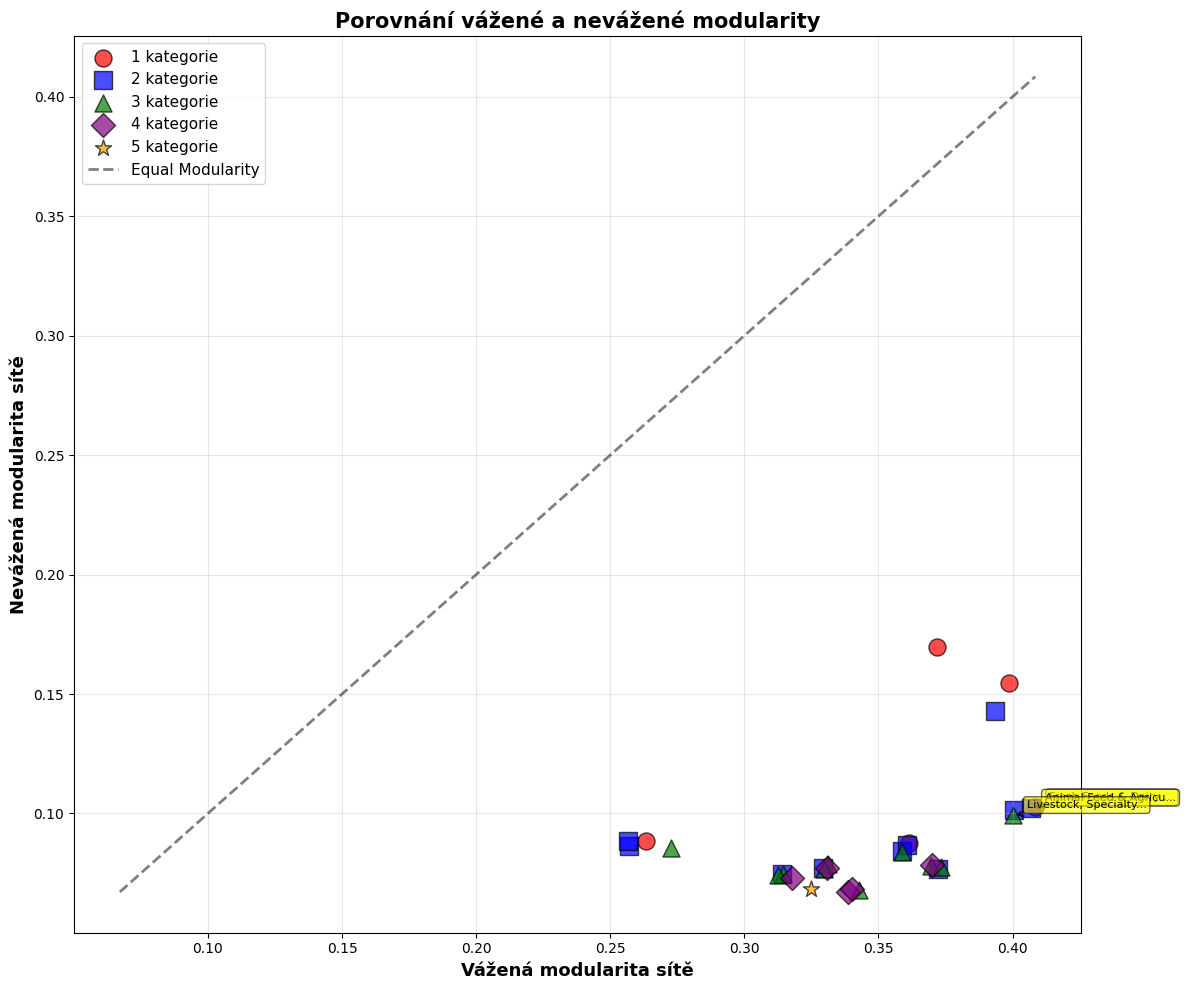

In [201]:
fig, ax = plt.subplots(figsize=(12, 10))

# Create scatter plot with different colors for each combo size
colors_map = {1: 'red', 2: 'blue', 3: 'green', 4: 'purple', 5: 'orange'}
markers_map = {1: 'o', 2: 's', 3: '^', 4: 'D', 5: '*'}

for size in combo_sizes:
    df_subset = comparison_df[comparison_df['combo_size'] == size]
    ax.scatter(df_subset['modularity_weighted'], df_subset['modularity_unweighted'],
              c=colors_map[size], marker=markers_map[size], s=150, alpha=0.7,
              label=f'{size} kategorie' if size == 1 else f'{size} kategorie',
              edgecolors='black', linewidths=1)

# Add diagonal line
max_val = max(comparison_df['modularity_weighted'].max(), comparison_df['modularity_unweighted'].max())
min_val = min(comparison_df['modularity_weighted'].min(), comparison_df['modularity_unweighted'].min())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, linewidth=2, label='Equal Modularity')

ax.set_xlabel('Vážená modularita sítě', fontsize=13, weight='bold')
ax.set_ylabel('Nevážená modularita sítě', fontsize=13, weight='bold')
ax.set_title('Porovnání vážené a nevážené modularity', fontsize=15, weight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(alpha=0.3)

# Annotate extreme points
top_diff = comparison_df.nlargest(3, 'modularity_diff')
for _, row in top_diff.iterrows():
    ax.annotate(f"{row['category_names'][:20]}...", 
               (row['modularity_weighted'], row['modularity_unweighted']),
               fontsize=8, xytext=(10, 5), textcoords='offset points',
               bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.6),
               arrowprops=dict(arrowstyle="->", lw=1))

plt.tight_layout()
plt.savefig(COMMUNITY_DIR / "weighted_vs_unweighted_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

### Proměrný trend modularity s chybovými úseky

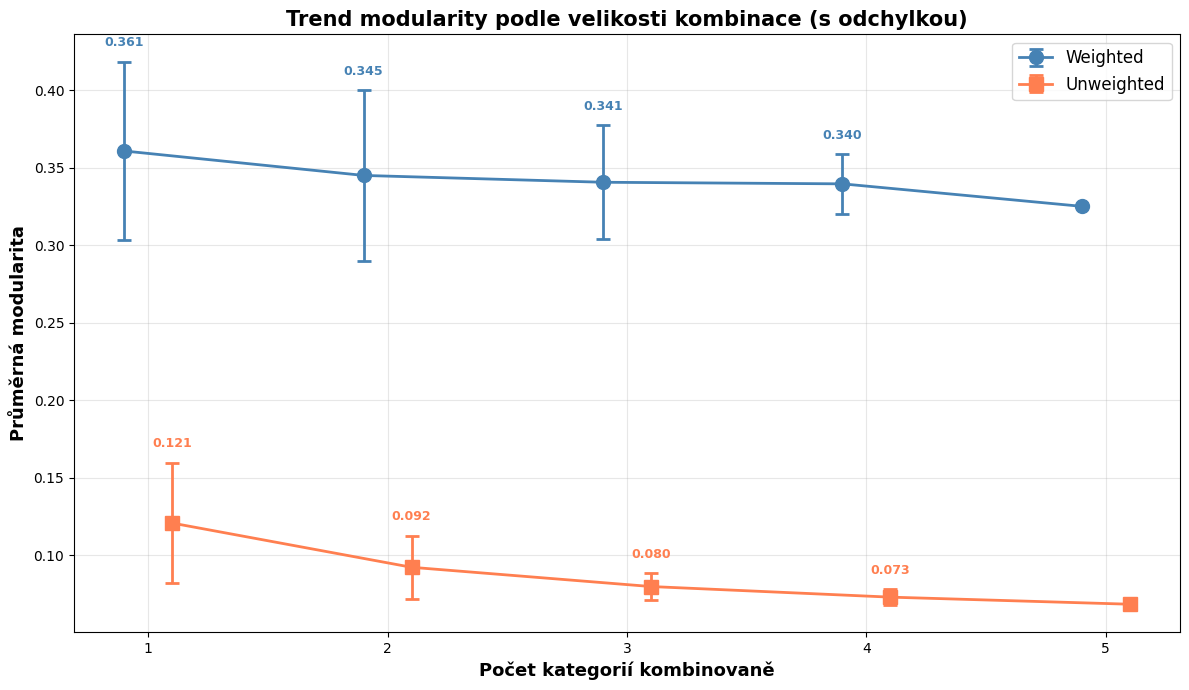

In [202]:
fig, ax = plt.subplots(figsize=(12, 7))

# Calculate means and std for each combo size
means_w = []
stds_w = []
means_uw = []
stds_uw = []

for size in combo_sizes:
    means_w.append(df_weighted_combos[df_weighted_combos['combo_size'] == size]['modularity'].mean())
    stds_w.append(df_weighted_combos[df_weighted_combos['combo_size'] == size]['modularity'].std())
    means_uw.append(df_unweighted_combos[df_unweighted_combos['combo_size'] == size]['modularity'].mean())
    stds_uw.append(df_unweighted_combos[df_unweighted_combos['combo_size'] == size]['modularity'].std())

x = np.array(combo_sizes)

# Plot with error bars
ax.errorbar(x - 0.1, means_w, yerr=stds_w, fmt='o-', linewidth=2, markersize=10,
           capsize=5, capthick=2, label='Weighted', color='steelblue')
ax.errorbar(x + 0.1, means_uw, yerr=stds_uw, fmt='s-', linewidth=2, markersize=10,
           capsize=5, capthick=2, label='Unweighted', color='coral')

ax.set_xlabel('Počet kategorií kombinovaně', fontsize=13, weight='bold')
ax.set_ylabel('Průměrná modularita', fontsize=13, weight='bold')
ax.set_title('Trend modularity podle velikosti kombinace (s odchylkou)', fontsize=15, weight='bold')
ax.set_xticks(combo_sizes)
ax.legend(fontsize=12, loc='best')
ax.grid(alpha=0.3)

# Annotate values
for i, size in enumerate(combo_sizes):
    ax.text(size - 0.1, means_w[i] + stds_w[i] + 0.01, f'{means_w[i]:.3f}', 
           ha='center', fontsize=9, color='steelblue', weight='bold')
    ax.text(size + 0.1, means_uw[i] + stds_uw[i] + 0.01, f'{means_uw[i]:.3f}', 
           ha='center', fontsize=9, color='coral', weight='bold')

plt.tight_layout()
plt.savefig(COMMUNITY_DIR / "modularity_trend_with_errorbars.png", dpi=300, bbox_inches='tight')
plt.show()

### Heatmapa párové modularity kategorií (kombinace 2 kategorií)

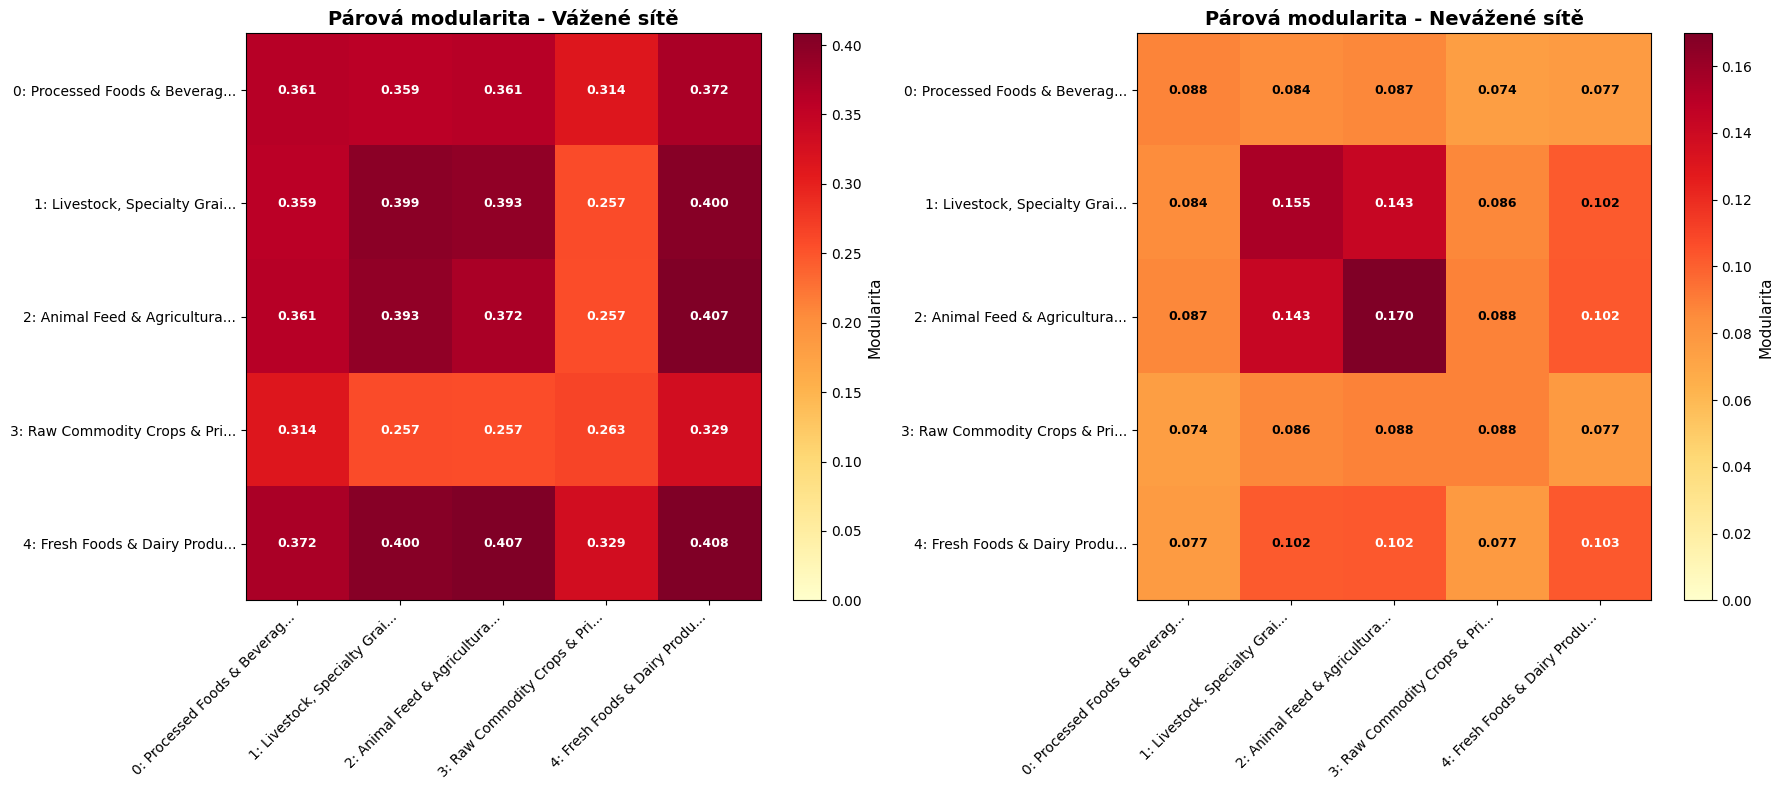

In [203]:
# Create matrices for 2-category combinations
size2_weighted = df_weighted_combos[df_weighted_combos['combo_size'] == 2]
size2_unweighted = df_unweighted_combos[df_unweighted_combos['combo_size'] == 2]

n_cats = len(categories)
mod_matrix_w = np.zeros((n_cats, n_cats))
mod_matrix_uw = np.zeros((n_cats, n_cats))

for _, row in size2_weighted.iterrows():
    cats = row['categories']
    mod_matrix_w[cats[0], cats[1]] = row['modularity']
    mod_matrix_w[cats[1], cats[0]] = row['modularity']

for _, row in size2_unweighted.iterrows():
    cats = row['categories']
    mod_matrix_uw[cats[0], cats[1]] = row['modularity']
    mod_matrix_uw[cats[1], cats[0]] = row['modularity']

# Fill diagonal with single category modularities
for cat in categories:
    mod_w = df_weighted_combos[(df_weighted_combos['combo_size'] == 1) & 
                               (df_weighted_combos['categories'].apply(lambda x: x[0] == cat))]['modularity'].values[0]
    mod_uw = df_unweighted_combos[(df_unweighted_combos['combo_size'] == 1) & 
                                  (df_unweighted_combos['categories'].apply(lambda x: x[0] == cat))]['modularity'].values[0]
    mod_matrix_w[cat, cat] = mod_w
    mod_matrix_uw[cat, cat] = mod_uw

# Plot heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

cat_labels = [f"{cat}: {get_category_name(cat)[:25]}..." if len(get_category_name(cat)) > 25 
              else f"{cat}: {get_category_name(cat)}" for cat in categories]

# Weighted heatmap
im1 = ax1.imshow(mod_matrix_w, cmap='YlOrRd', aspect='auto', vmin=0, vmax=mod_matrix_w.max())
ax1.set_xticks(range(n_cats))
ax1.set_yticks(range(n_cats))
ax1.set_xticklabels(cat_labels, rotation=45, ha='right', fontsize=10)
ax1.set_yticklabels(cat_labels, fontsize=10)
ax1.set_title('Párová modularita - Vážené sítě', fontsize=14, weight='bold')
cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('Modularita', fontsize=11)

# Add text annotations
for i in range(n_cats):
    for j in range(n_cats):
        if mod_matrix_w[i, j] > 0:
            text_color = "white" if mod_matrix_w[i, j] > mod_matrix_w.max() * 0.6 else "black"
            ax1.text(j, i, f'{mod_matrix_w[i, j]:.3f}',
                    ha="center", va="center", color=text_color, fontsize=9, weight='bold')

# Unweighted heatmap
im2 = ax2.imshow(mod_matrix_uw, cmap='YlOrRd', aspect='auto', vmin=0, vmax=mod_matrix_uw.max())
ax2.set_xticks(range(n_cats))
ax2.set_yticks(range(n_cats))
ax2.set_xticklabels(cat_labels, rotation=45, ha='right', fontsize=10)
ax2.set_yticklabels(cat_labels, fontsize=10)
ax2.set_title('Párová modularita - Nevážené sítě', fontsize=14, weight='bold')
cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label('Modularita', fontsize=11)

# Add text annotations
for i in range(n_cats):
    for j in range(n_cats):
        if mod_matrix_uw[i, j] > 0:
            text_color = "white" if mod_matrix_uw[i, j] > mod_matrix_uw.max() * 0.6 else "black"
            ax2.text(j, i, f'{mod_matrix_uw[i, j]:.3f}',
                    ha="center", va="center", color=text_color, fontsize=9, weight='bold')

plt.tight_layout()
plt.savefig(COMMUNITY_DIR / "pairwise_modularity_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

### Počet detekovaných komunit podle velikosti kombinace kategorií vrstev

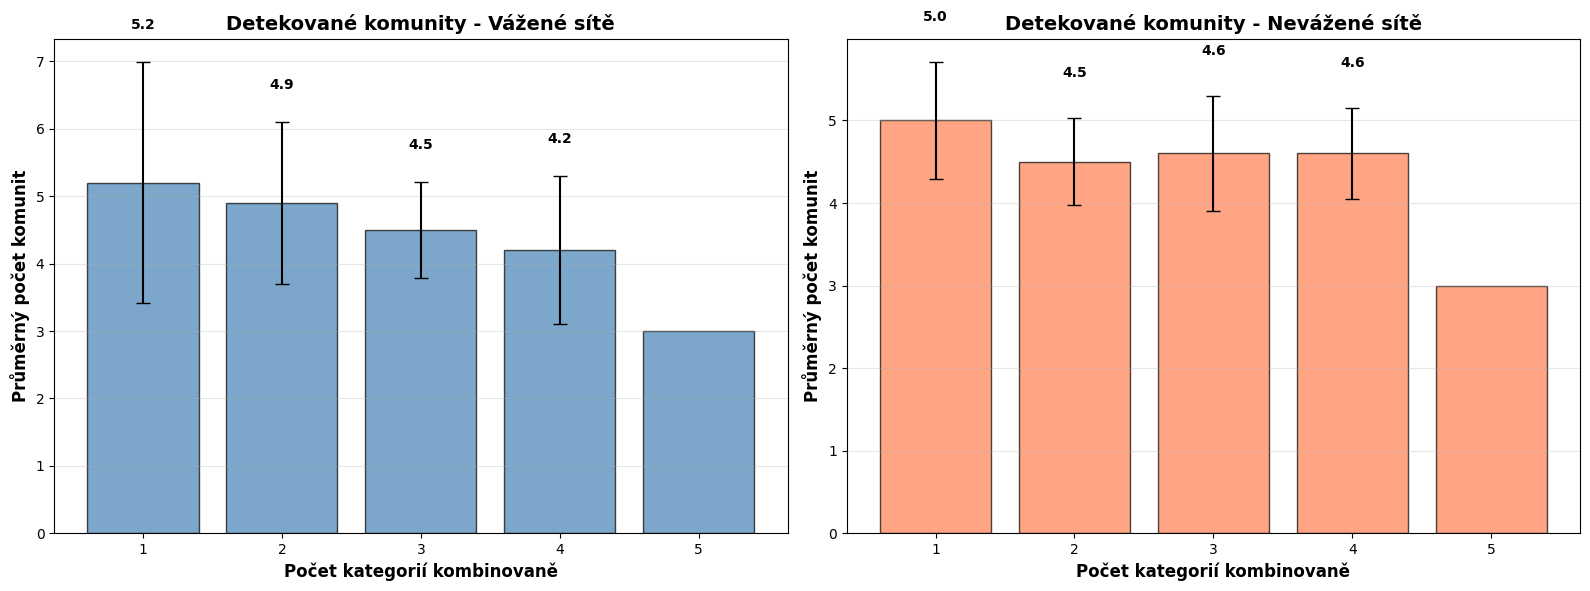

In [204]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Weighted - Number of communities by combo size
mean_comm_w = [df_weighted_combos[df_weighted_combos['combo_size'] == size]['num_communities'].mean() 
               for size in combo_sizes]
std_comm_w = [df_weighted_combos[df_weighted_combos['combo_size'] == size]['num_communities'].std() 
              for size in combo_sizes]

ax1.bar(combo_sizes, mean_comm_w, color='steelblue', alpha=0.7, edgecolor='black', yerr=std_comm_w, capsize=5)
ax1.set_xlabel('Počet kategorií kombinovaně', fontsize=12, weight='bold')
ax1.set_ylabel('Průměrný počet komunit', fontsize=12, weight='bold')
ax1.set_title('Detekované komunity - Vážené sítě', fontsize=14, weight='bold')
ax1.set_xticks(combo_sizes)
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for i, (size, val) in enumerate(zip(combo_sizes, mean_comm_w)):
    ax1.text(size, val + std_comm_w[i] + 0.5, f'{val:.1f}', ha='center', fontsize=10, weight='bold')

# Unweighted - Number of communities by combo size
mean_comm_uw = [df_unweighted_combos[df_unweighted_combos['combo_size'] == size]['num_communities'].mean() 
                for size in combo_sizes]
std_comm_uw = [df_unweighted_combos[df_unweighted_combos['combo_size'] == size]['num_communities'].std() 
               for size in combo_sizes]

ax2.bar(combo_sizes, mean_comm_uw, color='coral', alpha=0.7, edgecolor='black', yerr=std_comm_uw, capsize=5)
ax2.set_xlabel('Počet kategorií kombinovaně', fontsize=12, weight='bold')
ax2.set_ylabel('Průměrný počet komunit', fontsize=12, weight='bold')
ax2.set_title('Detekované komunity - Nevážené sítě', fontsize=14, weight='bold')
ax2.set_xticks(combo_sizes)
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for i, (size, val) in enumerate(zip(combo_sizes, mean_comm_uw)):
    ax2.text(size, val + std_comm_uw[i] + 0.5, f'{val:.1f}', ha='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.savefig(COMMUNITY_DIR / "num_communities_by_combo_size.png", dpi=300, bbox_inches='tight')
plt.show()

### Všechny kombinace přehledně (strip plot)

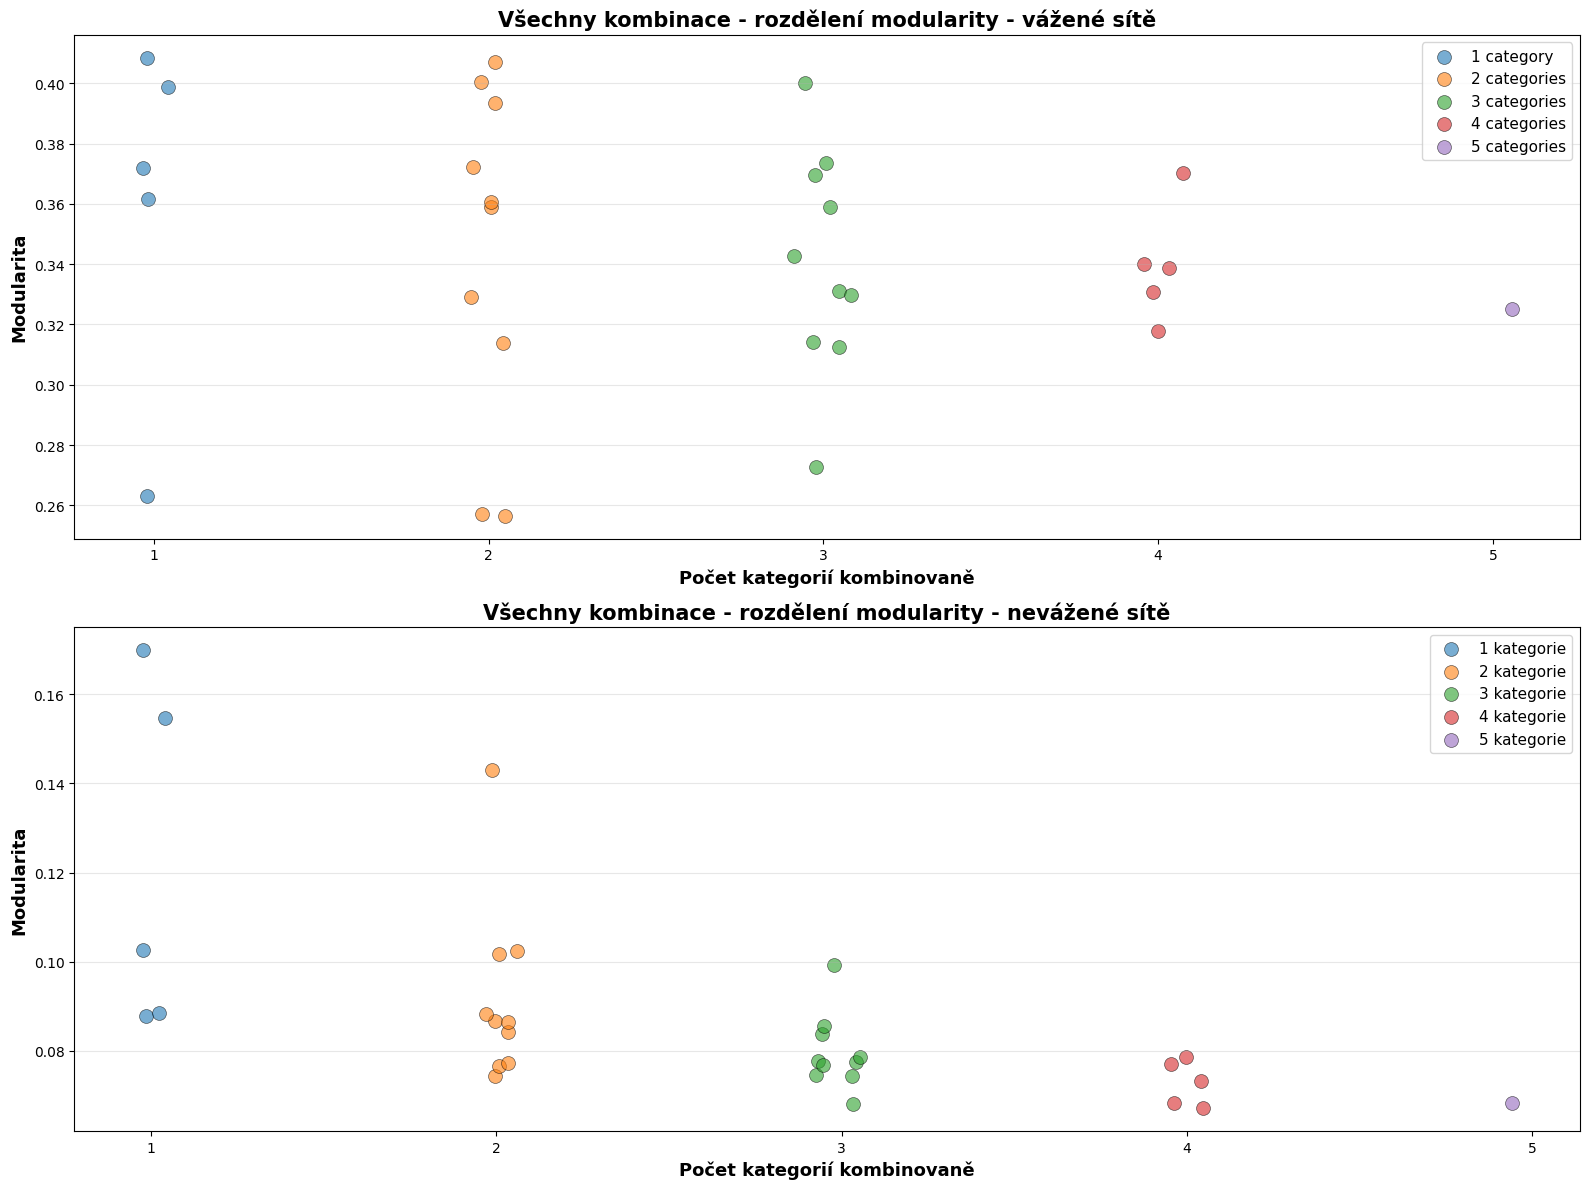

In [205]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# Weighted strip plot
for size in combo_sizes:
    df_subset = df_weighted_combos[df_weighted_combos['combo_size'] == size]
    y_values = df_subset['modularity'].values
    x_values = np.random.normal(size, 0.04, size=len(y_values))  # Add jitter
    ax1.scatter(x_values, y_values, alpha=0.6, s=100, 
               color=f'C{size-1}', edgecolors='black', linewidths=0.5,
               label=f'{size} category' if size == 1 else f'{size} categories')

ax1.set_xlabel('Počet kategorií kombinovaně', fontsize=13, weight='bold')
ax1.set_ylabel('Modularita', fontsize=13, weight='bold')
ax1.set_title('Všechny kombinace - rozdělení modularity - vážené sítě', fontsize=15, weight='bold')
ax1.set_xticks(combo_sizes)
ax1.legend(loc='best', fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# Unweighted strip plot
for size in combo_sizes:
    df_subset = df_unweighted_combos[df_unweighted_combos['combo_size'] == size]
    y_values = df_subset['modularity'].values
    x_values = np.random.normal(size, 0.04, size=len(y_values))  # Add jitter
    ax2.scatter(x_values, y_values, alpha=0.6, s=100, 
               color=f'C{size-1}', edgecolors='black', linewidths=0.5,
               label=f'{size} kategorie' if size == 1 else f'{size} kategorie')

ax2.set_xlabel('Počet kategorií kombinovaně', fontsize=13, weight='bold')
ax2.set_ylabel('Modularita', fontsize=13, weight='bold')
ax2.set_title('Všechny kombinace - rozdělení modularity - nevážené sítě', fontsize=15, weight='bold')
ax2.set_xticks(combo_sizes)
ax2.legend(loc='best', fontsize=11)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(COMMUNITY_DIR / "all_combinations_strip_plot.png", dpi=300, bbox_inches='tight')
plt.show()

## Náhodná procházka